# Sistema de Registro Pedagógico Inteligente (RPI)
## Modelo de Machine Learning supervisado para la alerta temprana de no promoción
### Metodología **CRISP-ML(Q)** · Sistema Educativo Dominicano (MINERD) · Año escolar 2026-2027

---

**Fuente de datos:** `3RO_B_REGISTRO_ESCOLAR_2026_2027.xlsx` (libro de registro del docente).

**Problema:** en el Nivel Secundario dominicano el docente registra en un libro de Excel
las calificaciones por período, las prácticas por competencia y la asistencia diaria.
Toda esa información existe, pero **se consulta cuando ya es tarde**: el estudiante llega
a la prueba completiva o extraordinaria sin que nadie haya intervenido a tiempo.

**Lo que construimos aquí:** un modelo **supervisado de clasificación binaria** que,
usando únicamente la información disponible **al cierre del Período 2** (mitad del año),
estima la probabilidad de que un estudiante **no alcance los 70 puntos** en la
calificación final ordinaria de una asignatura, y la traduce en una banda de riesgo
(BAJO / MEDIO / ALTO) con recomendaciones pedagógicas concretas.

**Entregables del proyecto:**

| Entregable | Archivo | Rol |
|---|---|---|
| Cuaderno CRISP-ML(Q) | `notebooks/CRISP_ML_Registro_Pedagogico.ipynb` | Este documento |
| Módulo reutilizable | `src/registro_ia.py` | Extracción, reglas MINERD, simulación |
| Modelo entrenado | `models/modelo_riesgo.joblib` | Pipeline completo (preproceso + clasificador) |
| Tarjeta del modelo | `models/model_card.json` | Metadatos, métricas y limitaciones |
| Landing page | `landing/index.html` | Registro pedagógico con inferencia en el navegador |
| Aplicación | `app/streamlit_app.py` | Panel docente + predicción por lote |
| Dependencias | `requirements.txt` | Reproducibilidad del entorno |

---

### Las seis fases de CRISP-ML(Q)

| Fase | En este cuaderno |
|---|---|
| 1. Comprensión del negocio y de los datos | Secciones 1 y 2 |
| 2. Preparación de datos (*Data Engineering*) | Sección 3 |
| 3. Modelado (*ML Model Engineering*) | Sección 4 |
| 4. Evaluación y aseguramiento de calidad | Sección 5 |
| 5. Despliegue (*Deployment*) | Sección 6 |
| 6. Monitoreo y mantenimiento | Sección 7 |

> CRISP-ML(Q) se diferencia de CRISP-DM en dos puntos que aquí se respetan:
> fusiona la comprensión del negocio con la de los datos (no se puede definir el
> objetivo sin mirar los datos) y **añade el monitoreo como fase formal**, porque un
> modelo educativo se degrada cada año escolar.

---
## 0. Configuración del entorno

Se fijan la semilla, las rutas del proyecto y el estilo de los gráficos.
Todas las rutas son relativas a la raíz del proyecto, de modo que el cuaderno
funcione igual ejecutado desde `notebooks/` o desde la raíz.

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEMILLA = 42
np.random.seed(SEMILLA)

# --- Rutas del proyecto (funciona desde notebooks/ o desde la raíz) ---------
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_DATOS = RAIZ / "data"
DIR_CRUDO = DIR_DATOS / "raw"
DIR_PROC = DIR_DATOS / "processed"
DIR_MODELOS = RAIZ / "models"
DIR_FIGURAS = RAIZ / "reports" / "figuras"
for d in (DIR_PROC, DIR_MODELOS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# El módulo propio del proyecto vive en src/
sys.path.insert(0, str(RAIZ / "src"))
import registro_ia as rpi   # noqa: E402

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)
print("Raíz        :", RAIZ)

Python      : 3.12.3
pandas      : 3.0.2
numpy       : 2.4.4


scikit-learn: 1.8.0
Raíz        : /home/claude/proyecto


---
## 1. Fase 1 — Comprensión del negocio *(Business Understanding)*

### 1.1 Contexto institucional

El centro educativo evalúa según el currículo dominicano **por competencias**. Del libro
del docente se desprende la estructura real del proceso:

* **Cuatro competencias fundamentales** evaluadas en cada asignatura: `C1` Comunicativa,
  `C2` Pensamiento Lógico/Crítico/Creativo, `C3` Ética y Ciudadana, `C4` Científica y Tecnológica.
* **Cuatro períodos** (`P1`…`P4`), cada uno con su **Recuperación Pedagógica**.
* Cada período se compone de **actividades ponderadas** que suman 100 puntos
  (p. ej. *Participación 30 + Exposición 30 + Cuaderno 30 + Asistencia 10*).
* **Escala 0-100** con **70 puntos** como mínimo de promoción.
* Si la Calificación Final (C.F.) ordinaria es menor que 70, el estudiante va a
  **Prueba Completiva**: `C.C.F. = 50% C.F. + 50% C.E.C.`
* Si aún no alcanza 70, va a **Prueba Extraordinaria**: `C.EX.F. = 30% C.F. + 70% C.E.EX.`

Estas reglas están implementadas literalmente en `registro_ia.situacion_final()`.

### 1.2 Pregunta de negocio

> *¿Podemos identificar, al terminar el Período 2, cuáles estudiantes terminarán el año
> por debajo de 70 en una asignatura, con tiempo suficiente para intervenir?*

### 1.3 Formulación como problema de Machine Learning

| Elemento | Definición |
|---|---|
| **Tipo de aprendizaje** | Supervisado |
| **Tarea** | Clasificación binaria |
| **Unidad de análisis** | Un par *(estudiante, asignatura)* dentro de un año escolar |
| **Variable objetivo `y`** | `riesgo_no_promocion` = 1 si C.F. ordinaria < 70; 0 en caso contrario |
| **Momento de la predicción** | Corte del Período 2 (mitad del año escolar) |
| **Variables predictoras `X`** | Sólo lo observable hasta ese corte (ver §3.2) |

### 1.4 Criterios de éxito

**De negocio (pedagógicos)**
1. Detectar al menos el **80 % de los estudiantes que efectivamente reprobarían**
   (*recall* de la clase positiva ≥ 0.80). Dejar pasar un caso real es el error caro:
   significa un estudiante sin intervención.
2. Que las alertas sean manejables: no más de ~35 % del curso marcado en ALTO,
   porque el docente no puede dar seguimiento intensivo a media aula.
3. Cada alerta debe venir acompañada de **acciones concretas**, no solo de un número.

**Técnicos**
* `ROC-AUC` ≥ 0.85 y `F1` de la clase positiva ≥ 0.75 en el conjunto de prueba.
* Modelo **explicable**: el docente debe poder justificar la alerta ante la familia.
* Inferencia por debajo de 1 segundo y despliegue sin servidor en el navegador.

### 1.5 Riesgos y consideraciones éticas *(Quality Assurance de CRISP-ML(Q))*

| Riesgo | Mitigación adoptada |
|---|---|
| **Profecía autocumplida**: etiquetar a un niño como "de riesgo" baja las expectativas del docente | La salida se llama *alerta de acompañamiento*, nunca *predicción de fracaso*; el estudiante nunca ve su puntaje |
| **Sesgo por variables sensibles** | Se **excluyen** sexo, nacionalidad y nombre del conjunto de entrenamiento; se audita el desempeño por grado y tanda |
| **Fuga de datos** (*data leakage*) | Se eliminan explícitamente P3, P4 y la calificación final del vector de entrada |
| **Sobreconfianza en el modelo** | La decisión final es **siempre del docente**; el sistema es un apoyo, no un veredicto |
| **Privacidad** | El registro pedagógico no almacena datos personales en servicios externos: la inferencia de la landing page ocurre en el navegador |

---
## 2. Fase 1 (continuación) — Comprensión de los datos *(Data Understanding)*

### 2.1 Inventario del libro de registro

El archivo del docente tiene ocho hojas. Antes de modelar, hay que entender qué guarda cada una.

In [2]:
RUTA_LIBRO = rpi.localizar_libro()
if RUTA_LIBRO is None:
    raise FileNotFoundError(
        "No se encontró el libro de registro. Colóquelo en data/raw/ "
        f"con el nombre {rpi.NOMBRE_LIBRO_POR_DEFECTO}")

print("Libro localizado en:", RUTA_LIBRO)

hojas = pd.ExcelFile(RUTA_LIBRO, engine="openpyxl").sheet_names
descripcion_hojas = {
    "Asignaciones": "Actividades evaluadas por competencia y período, con su ponderación",
    "Calificación": "Notas P1-P4, promedios por competencia y situación final por estudiante",
    "Prácticas": "Puntaje de cada actividad por estudiante (insumo de la nota del período)",
    "Asistencia": "Registro diario P/A/T/E por estudiante y resumen mensual",
    "ACTA": "Acta oficial de calificaciones del curso",
    "Nuevos Estudiantes": "Altas de matrícula durante el año",
    "L": "Listado maestro de matrícula por curso y sección",
    "C": "Catálogo curricular: grado x asignatura x competencia",
}
inventario = pd.DataFrame(
    {"hoja": hojas,
     "contenido": [descripcion_hojas.get(h, "—") for h in hojas]})
inventario

Libro localizado en: /home/claude/proyecto/data/raw/3RO_B_REGISTRO_ESCOLAR_2026_2027.xlsx


,hoja,contenido
0,Asignaciones,Actividades evaluadas por competencia y períod...
1,Calificación,"Notas P1-P4, promedios por competencia y situa..."
2,Prácticas,Puntaje de cada actividad por estudiante (insu...
3,Asistencia,Registro diario P/A/T/E por estudiante y resum...
4,ACTA,Acta oficial de calificaciones del curso
5,Nuevos Estudiantes,Altas de matrícula durante el año
6,L,Listado maestro de matrícula por curso y sección
7,C,Catálogo curricular: grado x asignatura x comp...


In [3]:
resumen = rpi.resumen_libro(RUTA_LIBRO)
print("MATRÍCULA TOTAL          :", resumen["matricula_total"], "estudiantes")
print("CURSOS                   :", ", ".join(resumen["cursos"]))
print("DÍAS DE CLASE EN EL LIBRO:", resumen["dias_clase_registrados"],
      f"({resumen['primera_fecha']} a {resumen['ultima_fecha']})")
print("ASIGNATURAS EN CATÁLOGO  :", len(resumen["asignaturas"]))
print("COMPETENCIAS             :", ", ".join(resumen["competencias"]))
print()
print("Estudiantes por curso:")
for curso, n in resumen["estudiantes_por_curso"].items():
    print(f"  {curso:<8} {'█' * int(n / 2)} {n}")

MATRÍCULA TOTAL          : 195 estudiantes
CURSOS                   : 4TO A, 4TO B, 4TO C, 5TO A, 6TO A, 6TO B
DÍAS DE CLASE EN EL LIBRO: 238 (2026-08-31 a 2027-07-30)
ASIGNATURAS EN CATÁLOGO  : 20
COMPETENCIAS             : C1, C2, C3, C4

Estudiantes por curso:
  4TO A    ████████████████ 32
  4TO B    ████████████████ 32
  4TO C    █████████████████ 35
  5TO A    █████████████████████ 43
  6TO A    ███████████████ 30
  6TO B    ███████████ 23


In [4]:
estudiantes = rpi.extraer_estudiantes(RUTA_LIBRO)
catalogo = rpi.extraer_catalogo(RUTA_LIBRO)

print("Matrícula (primeras filas):")
display(estudiantes.head(8))
print("\nCatálogo curricular (asignatura x competencia):")
display(catalogo.head(8))
print("\nAsignaturas del catálogo:")
for a in sorted(catalogo["asignatura"].unique()):
    print("  •", a)

Matrícula (primeras filas):


,id_estudiante,aux,curso,nivel,seccion,numero,nombres,apellidos,estudiante
0,4TOA1,4TO A1,4TO A,4to,A,1,JEORDANY ESTEBAN,ABREU ESPINAL,Jeordany Esteban Abreu Espinal
1,4TOA2,4TO A2,4TO A,4to,A,2,ANYEUDI ALEXANDER,ARIAS DE LA CRUZ,Anyeudi Alexander Arias De La Cruz
2,4TOA3,4TO A3,4TO A,4to,A,3,KEILY FRANCHESCA,BELIVARD JOAZILE,Keily Franchesca Belivard Joazile
3,4TOA4,4TO A4,4TO A,4to,A,4,EIMY,BURGOS MONTERO,Eimy Burgos Montero
4,4TOA5,4TO A5,4TO A,4to,A,5,FREILIN SOLANGE,CABADA GARCIA,Freilin Solange Cabada Garcia
5,4TOA6,4TO A6,4TO A,4to,A,6,NICOLE,DE LA CRUZ LIRANZO,Nicole De La Cruz Liranzo
6,4TOA7,4TO A7,4TO A,4to,A,7,ANGEL GABRIEL,DE LOS SANTOS FLORENCIO,Angel Gabriel De Los Santos Florencio
7,4TOA8,4TO A8,4TO A,4to,A,8,JHORWAN,DIAZ GUERRERO,Jhorwan Diaz Guerrero



Catálogo curricular (asignatura x competencia):


,nivel,asignatura,competencia_cod,competencia,descripcion
0,1ro,Lengua Española,C1,Comunicativa,C1. Comunicativa. CE-LE1- Se comunica con clar...
1,1ro,Lengua Española,C2,"Pensamiento Lógico, Crítico y Creativo; Resolu...","C2. Pensamiento Lógico, Creativo y Crítico; Re..."
2,1ro,Lengua Española,C3,Ética y Ciudadana; Desarrollo Personal y Espir...,C3. Ética y Ciudadana; Desarrollo Personal y E...
3,1ro,Lengua Española,C4,Científica y Tecnológica; Ambiental y de la Salud,C4. Científica y Tecnológica; Ambiental y de l...
4,1ro,Lenguas Extranjeras - Inglés,C1,Comunicativa,C1. Comunicativa. CE-LEI1- Comprende y expresa...
5,1ro,Lenguas Extranjeras - Inglés,C2,"Pensamiento Lógico, Crítico y Creativo; Resolu...","C2. Pensamiento Lógico, Creativo y Crítico; Re..."
6,1ro,Lenguas Extranjeras - Inglés,C3,Ética y Ciudadana; Desarrollo Personal y Espir...,C3. Ética y Ciudadana; Desarrollo Personal y E...
7,1ro,Lenguas Extranjeras - Inglés,C4,Científica y Tecnológica; Ambiental y de la Salud,C4. Científica y Tecnológica; Ambiental y de l...



Asignaturas del catálogo:
  • Ciencias Sociales
  • Ciencias de la Naturaleza
  • Ciencias de la Naturaleza – Física
  • Ciencias de la Naturaleza – Química
  • Ciencias y Tecnología. Física y Computación
  • Ciencias y Tecnología. Química y Computación
  • Ciudadanía y Democracia Participativa
  • Educación Artística
  • Educación Física
  • Filosofía Social y Pensamiento Dominicano
  • Formación Integral Humana y Religiosa
  • Geografía Humana y Demografía
  • Humanidades y Ciencias Sociales. Análisis y Producción Literarias.
  • Humanidades y Lenguas Modernas. Análisis Crítico y Evaluación de Textos en Inglés.
  • Humanidades y Lenguas Modernas. Análisis y Producción de Textos Periodísticos y Publicitarios
  • Lengua Española
  • Lenguas Extranjeras - Francés
  • Lenguas Extranjeras - Inglés
  • Matemática
  • Matemática y Tecnología. Trigonometría, Cálculo Diferencial y Tecnología.


### 2.2 Hallazgo crítico: el libro está **vacío de calificaciones**

Al inspeccionar la hoja `Calificación` aparece el problema real del proyecto: el año escolar
2026-2027 **acaba de comenzar**, así que las notas son todas `0` y las fórmulas devuelven
`#DIV/0!`. **No hay etiquetas para aprender.**

Esta es una situación completamente normal en un proyecto real, y CRISP-ML(Q) obliga a
declararla en la fase de comprensión de datos en lugar de esconderla.

In [5]:
califs = pd.read_excel(RUTA_LIBRO, sheet_name="Calificación", header=None,
                       engine="openpyxl", skiprows=5, nrows=39,
                       usecols=[0, 1, 2, 3, 4, 5, 6])
califs.columns = ["no", "nombres", "apellidos", "P1", "P2", "P3", "P4"]
califs = califs.dropna(subset=["nombres"])

notas = califs[["P1", "P2", "P3", "P4"]].apply(pd.to_numeric, errors="coerce")
print("Celdas de calificación no vacías (> 0):", int((notas > 0).sum().sum()),
      "de", int(notas.size))
print("Por lo tanto: NO hay variable objetivo observada en el libro.\n")
display(califs.head(6))

Celdas de calificación no vacías (> 0): 3 de 156
Por lo tanto: NO hay variable objetivo observada en el libro.



,no,nombres,apellidos,P1,P2,P3,P4
0,1,AGRAMONTE,YASMIN RAFELINA,0,0,0,0
1,2,MERIANNY,ANGLERO PAULINO,0,0,0,0
2,3,YEIBY ADRIAN,ANTOINE MARTINEZ,0,0,0,0
3,4,BRIANA,ARCHIL ROXA,0,0,0,0
4,5,DIANA FRANCHESCA,CASADO ALMONTE,0,0,0,0
5,6,ARLENYS MAYLIN,CUELLO FERREIRA,0,0,0,0


### 2.3 Decisión metodológica: histórico sintético **calibrado**

Ante la ausencia de etiquetas hay tres caminos:

1. Esperar a que termine el año escolar → el proyecto no existe.
2. Usar un dataset público de otro país → no refleja la estructura del MINERD.
3. **Simular un histórico con la estructura real del centro** → camino elegido.

La simulación **no inventa la estructura**: reutiliza la matrícula real (195 estudiantes,
6 cursos), las asignaturas reales del catálogo y las reglas de promoción reales. Lo que
genera es el *proceso de desempeño* a partir de un modelo causal explícito y documentado:

```text
habilidad_latente ~ Normal(0, 1)
asistencia        = f(habilidad, apoyo familiar, sobreedad) + ruido
nota_periodo      = g(habilidad, asistencia, entregas, participación, apoyo, dificultad) + ruido
C.F.              = promedio(P1..P4)
y = riesgo_no_promocion = 1 si C.F. < 70
```

**Consecuencia honesta que se declara en la tarjeta del modelo:** las métricas obtenidas
miden la capacidad del algoritmo de recuperar un proceso generador conocido; **no**
constituyen evidencia de desempeño sobre estudiantes reales. En cuanto el docente cargue
las notas reales del Período 1 y 2, se sustituye la celda de simulación por la lectura de
las hojas `Calificación`, `Prácticas` y `Asistencia`, y **todo el resto del cuaderno
funciona sin cambios**: ése es el motivo de haber fijado un contrato de datos en `src/`.

In [6]:
ANIOS_HISTORICOS = ("2023-2024", "2024-2025", "2025-2026")

datos = rpi.simular_historico(
    estudiantes=estudiantes,
    catalogo=catalogo,
    anios=ANIOS_HISTORICOS,
    asignaturas_por_estudiante=6,
    semilla=SEMILLA,
)

RUTA_DATASET = DIR_PROC / "dataset_registro_escolar.csv"
datos.to_csv(RUTA_DATASET, index=False, encoding="utf-8")

print(f"Registros generados : {len(datos):,}")
print(f"Columnas            : {datos.shape[1]}")
print(f"Años escolares      : {', '.join(ANIOS_HISTORICOS)}")
print(f"Guardado en         : {RUTA_DATASET.relative_to(RAIZ)}")
datos.head()

Registros generados : 3,510
Columnas            : 30
Años escolares      : 2023-2024, 2024-2025, 2025-2026
Guardado en         : data/processed/dataset_registro_escolar.csv


,anio_escolar,id_estudiante,estudiante,curso,nivel,seccion,asignatura,tanda,apoyo_familiar,calificacion_p1,...,participacion,sobreedad_anios,recuperaciones_p1_p2,horas_estudio_semana,calificacion_p3,calificacion_p4,calificacion_final,via_promocion,aprobado,riesgo_no_promocion
0,2023-2024,4TOA1,Jeordany Esteban Abreu Espinal,4TO A,4to,A,Lenguas Extranjeras - Inglés,Extendida,Medio,72.99,...,8.54,1,0,1.16,70.41,82.43,74.65,Ordinaria,1,0
1,2023-2024,4TOA1,Jeordany Esteban Abreu Espinal,4TO A,4to,A,Filosofía Social y Pensamiento Dominicano,Extendida,Medio,71.09,...,6.48,1,1,1.16,79.06,82.73,75.69,Ordinaria,1,0
2,2023-2024,4TOA1,Jeordany Esteban Abreu Espinal,4TO A,4to,A,Educación Física,Extendida,Medio,78.37,...,7.32,1,0,1.16,79.60,82.93,80.95,Ordinaria,1,0
3,2023-2024,4TOA1,Jeordany Esteban Abreu Espinal,4TO A,4to,A,Humanidades y Lenguas Modernas. Análisis y Pro...,Extendida,Medio,73.36,...,9.53,1,0,1.16,69.65,78.34,76.58,Ordinaria,1,0
4,2023-2024,4TOA1,Jeordany Esteban Abreu Espinal,4TO A,4to,A,Lengua Española,Extendida,Medio,62.52,...,5.09,1,2,1.16,73.51,71.98,68.11,Extraordinaria,1,1


### 2.4 Análisis exploratorio *(EDA)*

Antes de modelar hay que mirar los datos: distribución de la variable objetivo,
relación de cada predictor con el riesgo y correlaciones entre predictores.

In [7]:
print("=== CALIDAD DE LOS DATOS ===")
calidad = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "nulos": datos.isna().sum(),
    "% nulos": (datos.isna().mean() * 100).round(2),
    "únicos": datos.nunique(),
})
display(calidad)

print("Filas duplicadas:", int(datos.duplicated().sum()))
print("\n=== VARIABLE OBJETIVO ===")
conteo = datos[rpi.COLUMNA_OBJETIVO].value_counts().sort_index()
for clase, n in conteo.items():
    etiqueta = "Sin riesgo (aprueba en vía ordinaria)" if clase == 0 else "EN RIESGO (C.F. < 70)"
    print(f"  {clase} · {etiqueta:<40} {n:>5}  ({n / len(datos):.1%})")
print(f"\nRazón de desbalance: {conteo.max() / conteo.min():.2f} : 1  → desbalance moderado,")
print("manejable con class_weight='balanced' (no hace falta sobremuestreo).")

=== CALIDAD DE LOS DATOS ===


,tipo,nulos,% nulos,únicos
anio_escolar,str,0,0.0,3
id_estudiante,str,0,0.0,195
estudiante,str,0,0.0,195
curso,str,0,0.0,6
nivel,str,0,0.0,3
seccion,str,0,0.0,3
asignatura,str,0,0.0,20
tanda,str,0,0.0,3
apoyo_familiar,str,0,0.0,3
calificacion_p1,float64,0,0.0,2399


Filas duplicadas: 0

=== VARIABLE OBJETIVO ===
  0 · Sin riesgo (aprueba en vía ordinaria)     2480  (70.7%)
  1 · EN RIESGO (C.F. < 70)                     1030  (29.3%)

Razón de desbalance: 2.41 : 1  → desbalance moderado,
manejable con class_weight='balanced' (no hace falta sobremuestreo).


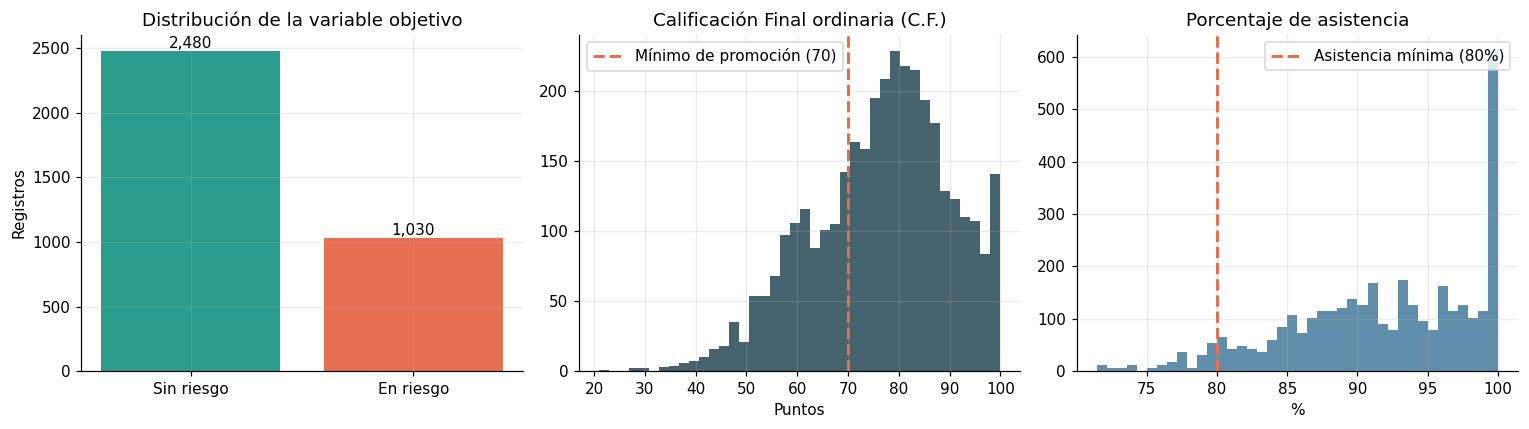

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(["Sin riesgo", "En riesgo"],
            [int(conteo.get(0, 0)), int(conteo.get(1, 0))],
            color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_ylabel("Registros")
for i, v in enumerate([int(conteo.get(0, 0)), int(conteo.get(1, 0))]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].hist(datos["calificacion_final"], bins=40, color="#264653", alpha=.85)
axes[1].axvline(70, color="#e76f51", lw=2, ls="--", label="Mínimo de promoción (70)")
axes[1].set_title("Calificación Final ordinaria (C.F.)")
axes[1].set_xlabel("Puntos")
axes[1].legend()

axes[2].hist(datos["pct_asistencia"], bins=40, color="#457b9d", alpha=.85)
axes[2].axvline(rpi.PARAMETROS_MINERD["asistencia_minima"], color="#e76f51", lw=2, ls="--",
                label="Asistencia mínima (80%)")
axes[2].set_title("Porcentaje de asistencia")
axes[2].set_xlabel("%")
axes[2].legend()

plt.tight_layout()
plt.savefig(DIR_FIGURAS / "01_distribuciones.png", bbox_inches="tight")
plt.show()

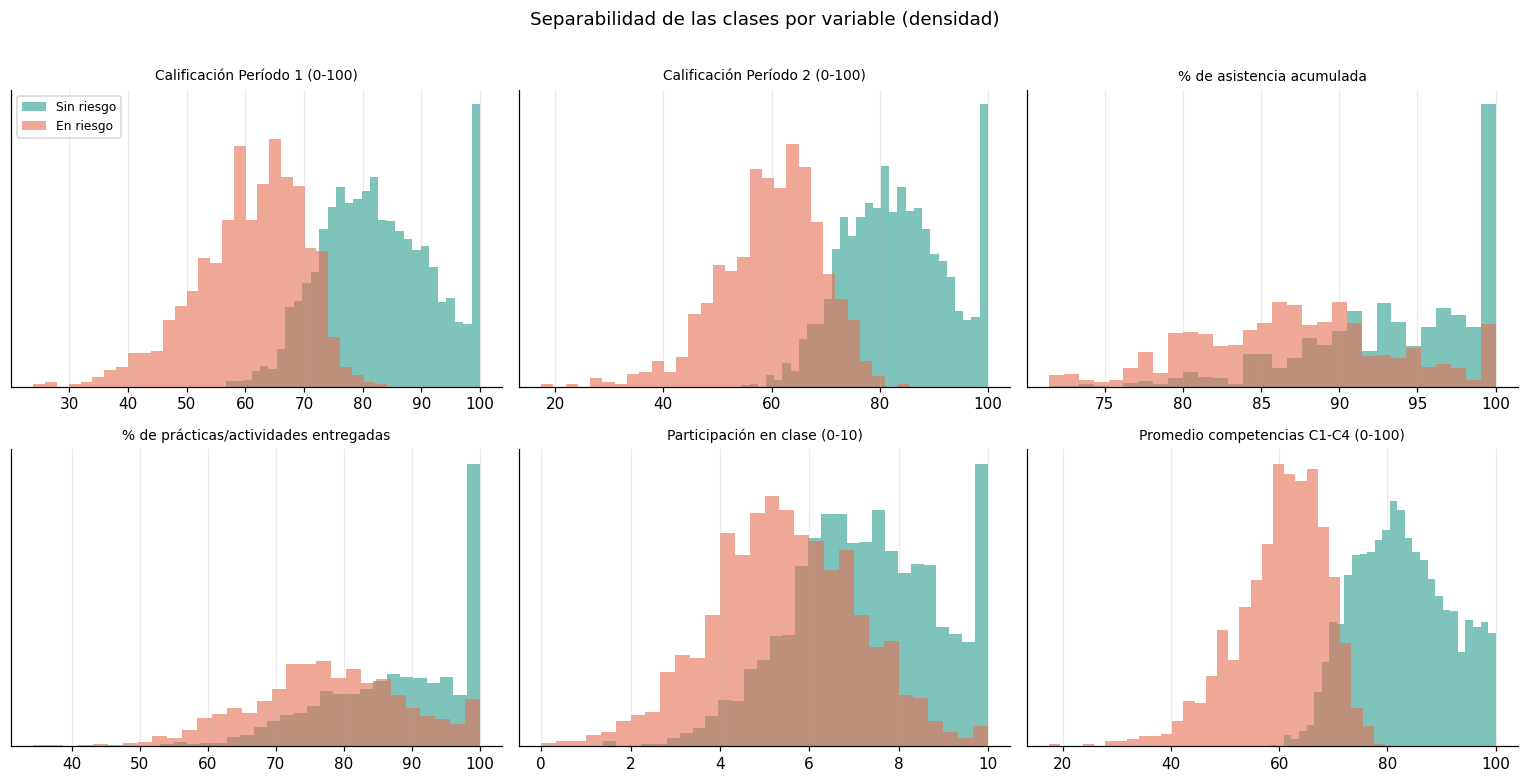

In [9]:
variables_clave = ["calificacion_p1", "calificacion_p2", "pct_asistencia",
                   "pct_practicas_entregadas", "participacion", "promedio_competencias"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, var in zip(axes.ravel(), variables_clave):
    for valor, color, etiqueta in [(0, "#2a9d8f", "Sin riesgo"), (1, "#e76f51", "En riesgo")]:
        serie = datos.loc[datos[rpi.COLUMNA_OBJETIVO] == valor, var]
        ax.hist(serie, bins=30, alpha=.6, color=color, label=etiqueta, density=True)
    ax.set_title(rpi.ESQUEMA_FEATURES.get(var, {}).get("etiqueta", var), fontsize=9)
    ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.suptitle("Separabilidad de las clases por variable (densidad)", y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "02_separabilidad.png", bbox_inches="tight")
plt.show()

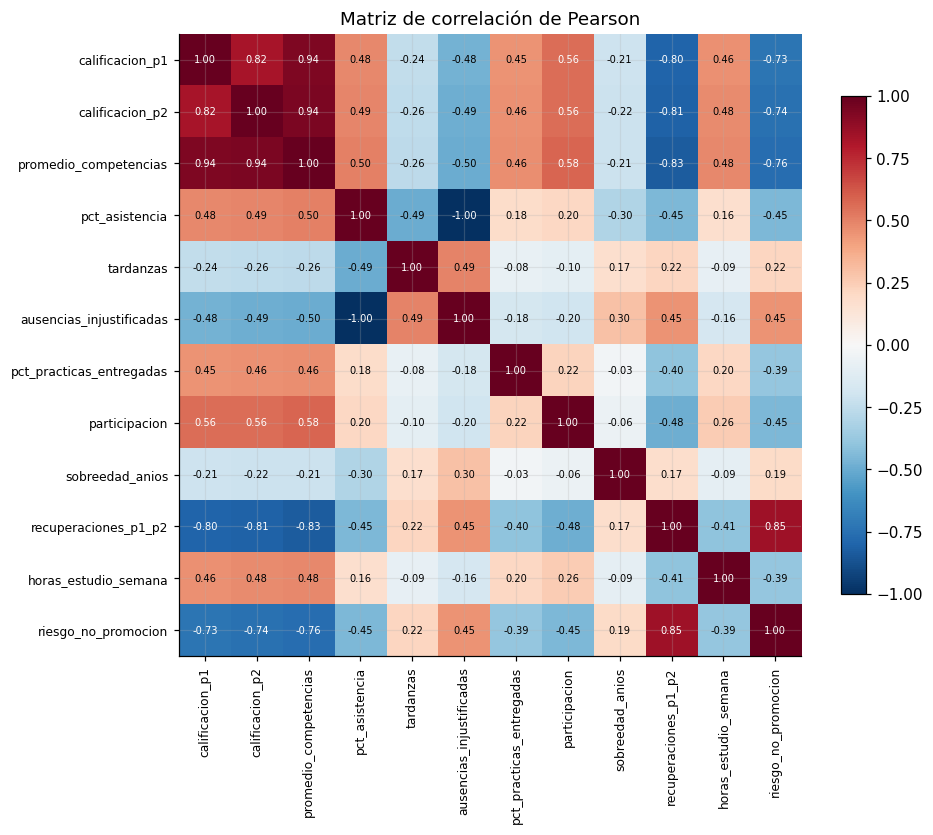

Correlación de cada predictor con el riesgo de no promoción:
promedio_competencias      -0.763
calificacion_p2            -0.745
calificacion_p1            -0.728
pct_asistencia             -0.451
participacion              -0.449
horas_estudio_semana       -0.388
pct_practicas_entregadas   -0.386
sobreedad_anios             0.188
tardanzas                   0.219
ausencias_injustificadas    0.449
recuperaciones_p1_p2        0.849


In [10]:
num_cols = rpi.COLUMNAS_NUMERICAS + [rpi.COLUMNA_OBJETIVO]
corr = datos[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(num_cols)), num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=6.5, color="black" if abs(corr.values[i, j]) < .55 else "white")
plt.colorbar(im, shrink=.8)
ax.set_title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "03_correlacion.png", bbox_inches="tight")
plt.show()

print("Correlación de cada predictor con el riesgo de no promoción:")
print(corr[rpi.COLUMNA_OBJETIVO].drop(rpi.COLUMNA_OBJETIVO)
      .sort_values().round(3).to_string())

In [11]:
tabla = (datos.groupby(["nivel"], observed=True)
         .agg(registros=(rpi.COLUMNA_OBJETIVO, "size"),
              tasa_riesgo=(rpi.COLUMNA_OBJETIVO, "mean"),
              cf_promedio=("calificacion_final", "mean"),
              asistencia=("pct_asistencia", "mean"))
         .round(3))
print("Tasa de riesgo por grado:")
display(tabla)

top_asig = (datos.groupby("asignatura", observed=True)[rpi.COLUMNA_OBJETIVO]
            .agg(["size", "mean"]).round(3)
            .sort_values("mean", ascending=False).head(10))
top_asig.columns = ["registros", "tasa_riesgo"]
print("Asignaturas con mayor tasa de riesgo:")
display(top_asig)

Tasa de riesgo por grado:


,registros,tasa_riesgo,cf_promedio,asistencia
nivel,,,,
4to,1782,0.305,76.246,91.707
5to,774,0.264,77.385,92.132
6to,954,0.297,76.026,91.456


Asignaturas con mayor tasa de riesgo:


,registros,tasa_riesgo
asignatura,,
Ciencias de la Naturaleza,117,0.368
Formación Integral Humana y Religiosa,238,0.349
Matemática,216,0.338
Ciudadanía y Democracia Participativa,49,0.327
Educación Artística,238,0.311
Humanidades y Lenguas Modernas. Análisis Crítico y Evaluación de Textos en Inglés.,246,0.305
"Matemática y Tecnología. Trigonometría, Cálculo Diferencial y Tecnología.",247,0.304
Lenguas Extranjeras - Francés,245,0.298
Ciencias y Tecnología. Química y Computación,68,0.294


**Lectura de la exploración.** Los predictores que más se asocian al riesgo son las
calificaciones de P1 y P2, el porcentaje de prácticas entregadas y la asistencia —
exactamente los tres indicadores que el docente ya registra a mano. Las clases se
solapan (no son linealmente separables al 100 %), lo que justifica probar modelos no
lineales además de la regresión logística.

---
## 3. Fase 2 — Preparación de los datos *(Data Engineering)*

### 3.1 Control de fuga de datos *(data leakage)*

Éste es el punto donde más proyectos de aula fallan. Si entrenamos con las notas de P3 y
P4, obtendremos un `ROC-AUC` de 0.99 **y un modelo completamente inútil**: para cuando
esas notas existen, el año ya terminó y no hay nada que prevenir.

Por eso se separan explícitamente las columnas en tres grupos y se **prohíbe** que las
del grupo C entren al modelo.

In [12]:
GRUPO_A_PREDICTORES = rpi.COLUMNAS_NUMERICAS + rpi.COLUMNAS_CATEGORICAS
GRUPO_B_IDENTIFICADORES = ["anio_escolar", "id_estudiante", "estudiante", "curso", "seccion"]
GRUPO_C_PROHIBIDAS = ["calificacion_p3", "calificacion_p4", "calificacion_final",
                      "via_promocion", "aprobado",
                      "competencia_c1", "competencia_c2", "competencia_c3", "competencia_c4"]

print("GRUPO A · Predictores admitidos (disponibles al corte de P2):")
for c in GRUPO_A_PREDICTORES:
    print(f"   ✓ {c}")
print("\nGRUPO B · Identificadores (trazabilidad, NO entran al modelo):")
print("   ", ", ".join(GRUPO_B_IDENTIFICADORES))
print("\nGRUPO C · PROHIBIDAS por fuga de datos (posteriores al corte):")
for c in GRUPO_C_PROHIBIDAS:
    print(f"   ✗ {c}")

fuga = set(GRUPO_A_PREDICTORES) & set(GRUPO_C_PROHIBIDAS)
assert not fuga, f"¡Fuga de datos detectada!: {fuga}"
print("\n✓ Verificación superada: ningún predictor pertenece al grupo prohibido.")

GRUPO A · Predictores admitidos (disponibles al corte de P2):
   ✓ calificacion_p1
   ✓ calificacion_p2
   ✓ promedio_competencias
   ✓ pct_asistencia
   ✓ tardanzas
   ✓ ausencias_injustificadas
   ✓ pct_practicas_entregadas
   ✓ participacion
   ✓ sobreedad_anios
   ✓ recuperaciones_p1_p2
   ✓ horas_estudio_semana
   ✓ nivel
   ✓ asignatura
   ✓ apoyo_familiar
   ✓ tanda

GRUPO B · Identificadores (trazabilidad, NO entran al modelo):
    anio_escolar, id_estudiante, estudiante, curso, seccion

GRUPO C · PROHIBIDAS por fuga de datos (posteriores al corte):
   ✗ calificacion_p3
   ✗ calificacion_p4
   ✗ calificacion_final
   ✗ via_promocion
   ✗ aprobado
   ✗ competencia_c1
   ✗ competencia_c2
   ✗ competencia_c3
   ✗ competencia_c4

✓ Verificación superada: ningún predictor pertenece al grupo prohibido.


### 3.2 Diccionario de datos del modelo

| Variable | Tipo | Rango | Significado pedagógico |
|---|---|---|---|
| `calificacion_p1` | numérica | 0-100 | Nota del Período 1 |
| `calificacion_p2` | numérica | 0-100 | Nota del Período 2 |
| `promedio_competencias` | numérica | 0-100 | Media de C1-C4 al corte |
| `pct_asistencia` | numérica | 0-100 | Asistencia acumulada |
| `tardanzas` | numérica | 0-60 | Cantidad de llegadas tarde |
| `ausencias_injustificadas` | numérica | 0-60 | Ausencias sin excusa |
| `pct_practicas_entregadas` | numérica | 0-100 | Cumplimiento de actividades |
| `participacion` | numérica | 0-10 | Valoración del docente |
| `sobreedad_anios` | numérica | 0-4 | Años por encima de la edad del grado |
| `recuperaciones_p1_p2` | numérica | 0-2 | Recuperaciones pedagógicas ya aplicadas |
| `horas_estudio_semana` | numérica | 0-20 | Estudio en casa reportado |
| `nivel` | categórica | 4to/5to/6to | Grado |
| `asignatura` | categórica | catálogo | Asignatura evaluada |
| `apoyo_familiar` | categórica | Bajo/Medio/Alto | Acompañamiento del hogar |
| `tanda` | categórica | Matutina/Vespertina/Extendida | Jornada |

**Variables deliberadamente excluidas:** nombre, sexo y nacionalidad. No aportan
capacidad predictiva legítima y su uso convertiría el sistema en un mecanismo de
discriminación estructural.

In [13]:
X = datos[GRUPO_A_PREDICTORES].copy()
y = datos[rpi.COLUMNA_OBJETIVO].astype(int).copy()

# --- Saneamiento defensivo: el origen real será Excel y formularios web ----
for col in rpi.COLUMNAS_NUMERICAS:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype("float64")
for col in rpi.COLUMNAS_CATEGORICAS:
    X[col] = X[col].astype("string").fillna("Desconocido").astype(object)

print("Forma de X:", X.shape, "| Forma de y:", y.shape)
print("Nulos tras el saneamiento:", int(X.isna().sum().sum()))
print("\nTipos de dato definitivos:")
print(X.dtypes.to_string())

Forma de X: (3510, 15) | Forma de y: (3510,)
Nulos tras el saneamiento: 0

Tipos de dato definitivos:
calificacion_p1             float64
calificacion_p2             float64
promedio_competencias       float64
pct_asistencia              float64
tardanzas                   float64
ausencias_injustificadas    float64
pct_practicas_entregadas    float64
participacion               float64
sobreedad_anios             float64
recuperaciones_p1_p2        float64
horas_estudio_semana        float64
nivel                        object
asignatura                   object
apoyo_familiar               object
tanda                        object


### 3.3 Partición estratificada y agrupada

Dos cuidados:

1. **Estratificación** por la variable objetivo, para que la proporción de casos en riesgo
   sea la misma en entrenamiento y prueba.
2. **Agrupación por estudiante** (`GroupShuffleSplit`): un mismo estudiante aparece en
   varias asignaturas. Si sus filas quedan repartidas entre entrenamiento y prueba, el
   modelo "reconoce" al estudiante y las métricas salen infladas. Todas las filas de un
   estudiante deben caer del mismo lado.

In [14]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_validate

grupos = (datos["anio_escolar"].astype(str) + "|" + datos["id_estudiante"].astype(str)).values

separador = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMILLA)
idx_entrena, idx_prueba = next(separador.split(X, y, groups=grupos))

X_entrena, X_prueba = X.iloc[idx_entrena].copy(), X.iloc[idx_prueba].copy()
y_entrena, y_prueba = y.iloc[idx_entrena].copy(), y.iloc[idx_prueba].copy()
grupos_entrena = grupos[idx_entrena]

print(f"Entrenamiento : {len(X_entrena):>5} registros · {y_entrena.mean():.1%} en riesgo")
print(f"Prueba        : {len(X_prueba):>5} registros · {y_prueba.mean():.1%} en riesgo")

solapan = set(grupos[idx_entrena]) & set(grupos[idx_prueba])
print(f"\nEstudiantes-año compartidos entre particiones: {len(solapan)}")
assert not solapan, "Hay solapamiento de grupos entre entrenamiento y prueba"
print("✓ Particiones independientes a nivel de estudiante.")

Entrenamiento :  2628 registros · 28.7% en riesgo
Prueba        :   882 registros · 31.4% en riesgo

Estudiantes-año compartidos entre particiones: 0
✓ Particiones independientes a nivel de estudiante.


### 3.4 Pipeline de preprocesamiento

Todo el preprocesamiento va **dentro** de un `Pipeline` de scikit-learn. Esto no es un
capricho de estilo: garantiza que la media y la desviación usadas para estandarizar se
calculen **sólo** con los datos de entrenamiento (si no, hay fuga), y permite guardar
preprocesamiento y modelo en un único archivo que la app puede cargar sin repetir código.

`OneHotEncoder` se construye con una función de compatibilidad porque el parámetro cambió
de nombre (`sparse` → `sparse_output`) en scikit-learn 1.2; así el cuaderno corre igual en
versiones anteriores y posteriores sin lanzar `TypeError`.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def crear_onehot():
    '''OneHotEncoder compatible con scikit-learn <1.2 y >=1.2 (evita TypeError).'''
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


tuberia_numerica = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])

tuberia_categorica = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", crear_onehot()),
])

preprocesador = ColumnTransformer(
    transformers=[
        ("num", tuberia_numerica, rpi.COLUMNAS_NUMERICAS),
        ("cat", tuberia_categorica, rpi.COLUMNAS_CATEGORICAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

demo = preprocesador.fit(X_entrena, y_entrena)
nombres_features = list(demo.get_feature_names_out())
print(f"Variables de entrada : {X_entrena.shape[1]}")
print(f"Variables tras codificar: {len(nombres_features)}")
print("Primeras 20:", nombres_features[:20])

Variables de entrada : 15
Variables tras codificar: 40
Primeras 20: ['calificacion_p1', 'calificacion_p2', 'promedio_competencias', 'pct_asistencia', 'tardanzas', 'ausencias_injustificadas', 'pct_practicas_entregadas', 'participacion', 'sobreedad_anios', 'recuperaciones_p1_p2', 'horas_estudio_semana', 'nivel_4to', 'nivel_5to', 'nivel_6to', 'asignatura_Ciencias Sociales', 'asignatura_Ciencias de la Naturaleza', 'asignatura_Ciencias de la Naturaleza – Física', 'asignatura_Ciencias de la Naturaleza – Química', 'asignatura_Ciencias y Tecnología. Física y Computación', 'asignatura_Ciencias y Tecnología. Química y Computación']


---
## 4. Fase 3 — Modelado *(ML Model Engineering)*

### 4.1 Modelos candidatos y por qué

| Modelo | Razón de inclusión |
|---|---|
| **Regresión Logística** | Línea base interpretable; sus coeficientes se exportan a la landing page para que prediga sin servidor |
| **Árbol de Decisión** | Reglas legibles que el docente puede leer literalmente |
| **Random Forest** | Captura interacciones (p. ej. baja asistencia *y* pocas entregas) y es robusto |
| **Gradient Boosting Histográfico** | Suele ser el más preciso en datos tabulares |

Todos con `class_weight='balanced'` donde el algoritmo lo permite, para compensar el
desbalance sin sobremuestrear.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidatos = {
    "Regresión Logística": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=SEMILLA),
    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=25, class_weight="balanced", random_state=SEMILLA),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=5, n_jobs=-1,
        class_weight="balanced_subsample", random_state=SEMILLA),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_depth=6,
        early_stopping=True, random_state=SEMILLA),
}

metricas = ["roc_auc", "f1", "precision", "recall", "balanced_accuracy"]
validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

filas_cv = []
for nombre, estimador in candidatos.items():
    tuberia = Pipeline([("preproceso", preprocesador), ("modelo", estimador)])
    puntajes = cross_validate(tuberia, X_entrena, y_entrena, cv=validacion,
                              scoring=metricas, n_jobs=-1, error_score="raise")
    fila = {"modelo": nombre}
    for m in metricas:
        fila[m] = float(np.mean(puntajes[f"test_{m}"]))
        fila[f"{m}_sd"] = float(np.std(puntajes[f"test_{m}"]))
    fila["tiempo_s"] = float(np.mean(puntajes["fit_time"]))
    filas_cv.append(fila)
    print(f"{nombre:<22} ROC-AUC={fila['roc_auc']:.4f} (±{fila['roc_auc_sd']:.4f})  "
          f"F1={fila['f1']:.4f}  Recall={fila['recall']:.4f}")

comparativa = pd.DataFrame(filas_cv).set_index("modelo").sort_values("roc_auc", ascending=False)
display(comparativa[["roc_auc", "f1", "precision", "recall", "balanced_accuracy", "tiempo_s"]].round(4))

Regresión Logística    ROC-AUC=0.9886 (±0.0026)  F1=0.9034  Recall=0.9495
Árbol de Decisión      ROC-AUC=0.9722 (±0.0067)  F1=0.8673  Recall=0.9456


Random Forest          ROC-AUC=0.9867 (±0.0036)  F1=0.9003  Recall=0.9402


Gradient Boosting      ROC-AUC=0.9864 (±0.0033)  F1=0.8982  Recall=0.8937


,roc_auc,f1,precision,recall,balanced_accuracy,tiempo_s
modelo,,,,,,
Regresión Logística,0.9886,0.9034,0.8624,0.9495,0.9441,0.0172
Random Forest,0.9867,0.9003,0.8645,0.9402,0.9402,1.0074
Gradient Boosting,0.9864,0.8982,0.9043,0.8937,0.9276,0.1565
Árbol de Decisión,0.9722,0.8673,0.8011,0.9456,0.9256,0.0193


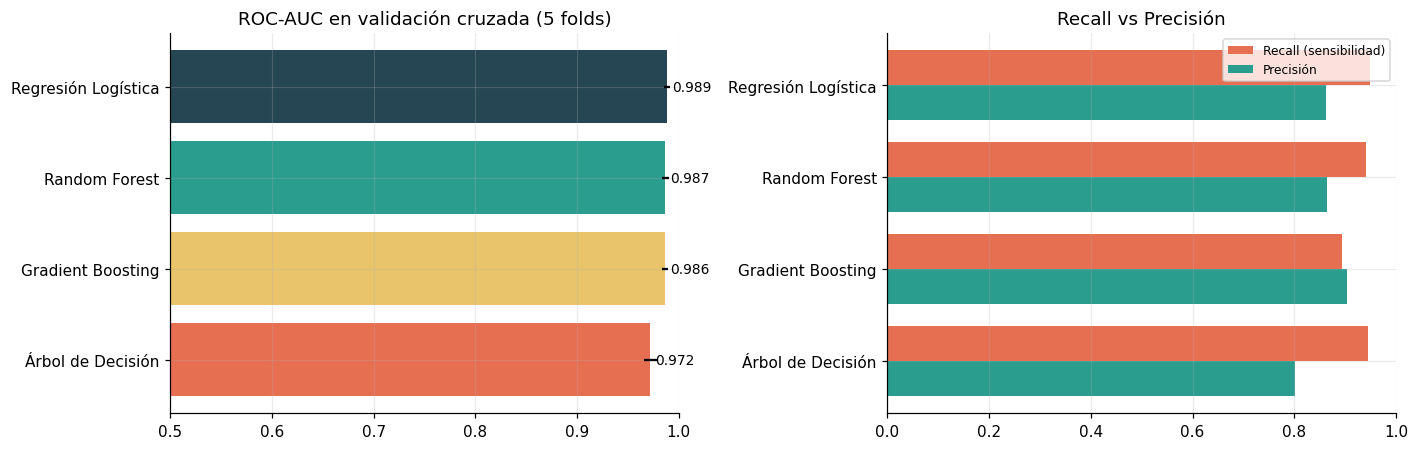

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
orden = comparativa.index.tolist()
colores = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]

axes[0].barh(orden, comparativa["roc_auc"], xerr=comparativa["roc_auc_sd"],
             color=colores[:len(orden)])
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title("ROC-AUC en validación cruzada (5 folds)")
axes[0].invert_yaxis()
for i, v in enumerate(comparativa["roc_auc"]):
    axes[0].text(v + .005, i, f"{v:.3f}", va="center", fontsize=9)

ancho = 0.38
posiciones = np.arange(len(orden))
axes[1].barh(posiciones - ancho / 2, comparativa["recall"], ancho,
             label="Recall (sensibilidad)", color="#e76f51")
axes[1].barh(posiciones + ancho / 2, comparativa["precision"], ancho,
             label="Precisión", color="#2a9d8f")
axes[1].set_yticks(posiciones, orden)
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)
axes[1].set_title("Recall vs Precisión")

plt.tight_layout()
plt.savefig(DIR_FIGURAS / "04_comparativa_modelos.png", bbox_inches="tight")
plt.show()

### 4.2 Ajuste de hiperparámetros del modelo ganador

Se refina el mejor candidato con `GridSearchCV`, optimizando `recall` sin sacrificar
demasiada precisión. La métrica de selección es **F2** (pondera el recall al doble que la
precisión), coherente con el criterio de negocio: *dejar pasar a un estudiante en riesgo
cuesta mucho más que revisar de más a uno que iba bien*.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer

f2 = make_scorer(fbeta_score, beta=2, zero_division=0)
mejor_nombre = comparativa.index[0]
print("Modelo con mejor ROC-AUC en CV:", mejor_nombre)

rejillas = {
    "Regresión Logística": {"modelo__C": [0.05, 0.25, 1.0, 4.0],
                            "modelo__penalty": ["l2"]},
    "Árbol de Decisión": {"modelo__max_depth": [4, 5, 7, 9],
                          "modelo__min_samples_leaf": [10, 25, 40]},
    "Random Forest": {"modelo__n_estimators": [300, 500],
                      "modelo__max_depth": [8, 12, None],
                      "modelo__min_samples_leaf": [3, 5, 10]},
    "Gradient Boosting": {"modelo__learning_rate": [0.04, 0.08],
                          "modelo__max_iter": [200, 400],
                          "modelo__max_leaf_nodes": [15, 31]},
}

tuberia_base = Pipeline([("preproceso", preprocesador),
                         ("modelo", candidatos[mejor_nombre])])

busqueda = GridSearchCV(
    estimator=tuberia_base,
    param_grid=rejillas[mejor_nombre],
    scoring={"f2": f2, "roc_auc": "roc_auc", "recall": "recall"},
    refit="f2",
    cv=validacion,
    n_jobs=-1,
    return_train_score=False,
)
busqueda.fit(X_entrena, y_entrena)

print("\nMejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor F2 en validación cruzada: {busqueda.best_score_:.4f}")

modelo_final = busqueda.best_estimator_

Modelo con mejor ROC-AUC en CV: Regresión Logística



Mejores hiperparámetros: {'modelo__C': 1.0, 'modelo__penalty': 'l2'}
Mejor F2 en validación cruzada: 0.9304


### 4.3 Calibración de probabilidades

Un docente va a leer "72 % de probabilidad de no alcanzar 70 puntos". Ese número debe
significar lo que dice: de cada 100 estudiantes con 72 %, aproximadamente 72 deberían
terminar reprobando. Los modelos de árboles tienden a dar probabilidades mal calibradas,
así que se aplica **calibración isotónica con validación cruzada** y se compara.

Brier sin calibrar : 0.0499
Brier calibrado    : 0.0428   (menor es mejor)

Modelo que pasa a producción: CALIBRADO (isotónico)


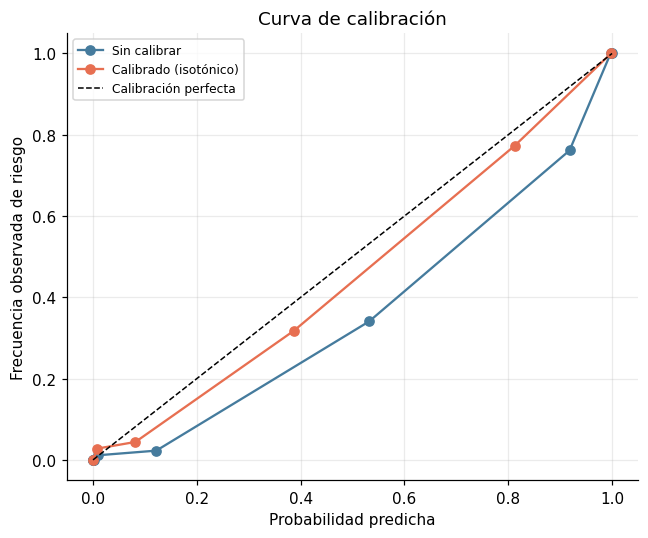

In [19]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

modelo_calibrado = CalibratedClassifierCV(
    estimator=busqueda.best_estimator_, method="isotonic", cv=5)
modelo_calibrado.fit(X_entrena, y_entrena)

prob_sin_cal = modelo_final.predict_proba(X_prueba)[:, 1]
prob_con_cal = modelo_calibrado.predict_proba(X_prueba)[:, 1]

brier_sin = brier_score_loss(y_prueba, prob_sin_cal)
brier_con = brier_score_loss(y_prueba, prob_con_cal)
print(f"Brier sin calibrar : {brier_sin:.4f}")
print(f"Brier calibrado    : {brier_con:.4f}   (menor es mejor)")

usar_calibrado = bool(brier_con < brier_sin)
modelo_produccion = modelo_calibrado if usar_calibrado else modelo_final
probabilidades = prob_con_cal if usar_calibrado else prob_sin_cal
print("\nModelo que pasa a producción:",
      "CALIBRADO (isotónico)" if usar_calibrado else "SIN CALIBRAR (ya estaba bien ajustado)")

fig, ax = plt.subplots(figsize=(6, 5))
for prob, etiqueta, color in [(prob_sin_cal, "Sin calibrar", "#457b9d"),
                              (prob_con_cal, "Calibrado (isotónico)", "#e76f51")]:
    frac_pos, media_pred = calibration_curve(y_prueba, prob, n_bins=10, strategy="quantile")
    ax.plot(media_pred, frac_pos, "o-", label=etiqueta, color=color)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia observada de riesgo")
ax.set_title("Curva de calibración")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "05_calibracion.png", bbox_inches="tight")
plt.show()

---
## 5. Fase 4 — Evaluación y aseguramiento de calidad

### 5.1 Desempeño en el conjunto de prueba

El conjunto de prueba (25 % de los registros, con estudiantes completamente distintos)
no se ha usado en ningún momento hasta esta celda.

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

UMBRAL_BASE = 0.50
predicciones = (probabilidades >= UMBRAL_BASE).astype(int)

resultados = {
    "Exactitud (accuracy)": accuracy_score(y_prueba, predicciones),
    "Precisión": precision_score(y_prueba, predicciones, zero_division=0),
    "Recall (sensibilidad)": recall_score(y_prueba, predicciones, zero_division=0),
    "F1": f1_score(y_prueba, predicciones, zero_division=0),
    "F2 (prioriza recall)": fbeta_score(y_prueba, predicciones, beta=2, zero_division=0),
    "ROC-AUC": roc_auc_score(y_prueba, probabilidades),
    "PR-AUC (avg precision)": average_precision_score(y_prueba, probabilidades),
}

print(f"=== DESEMPEÑO EN PRUEBA · umbral = {UMBRAL_BASE:.2f} ===")
for k, v in resultados.items():
    print(f"  {k:<24} {v:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_prueba, predicciones, zero_division=0,
                            target_names=["Sin riesgo", "En riesgo"]))

=== DESEMPEÑO EN PRUEBA · umbral = 0.50 ===
  Exactitud (accuracy)     0.9410
  Precisión                0.8893
  Recall (sensibilidad)    0.9278
  F1                       0.9081
  F2 (prioriza recall)     0.9198
  ROC-AUC                  0.9872
  PR-AUC (avg precision)   0.9745

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

  Sin riesgo       0.97      0.95      0.96       605
   En riesgo       0.89      0.93      0.91       277

    accuracy                           0.94       882
   macro avg       0.93      0.94      0.93       882
weighted avg       0.94      0.94      0.94       882



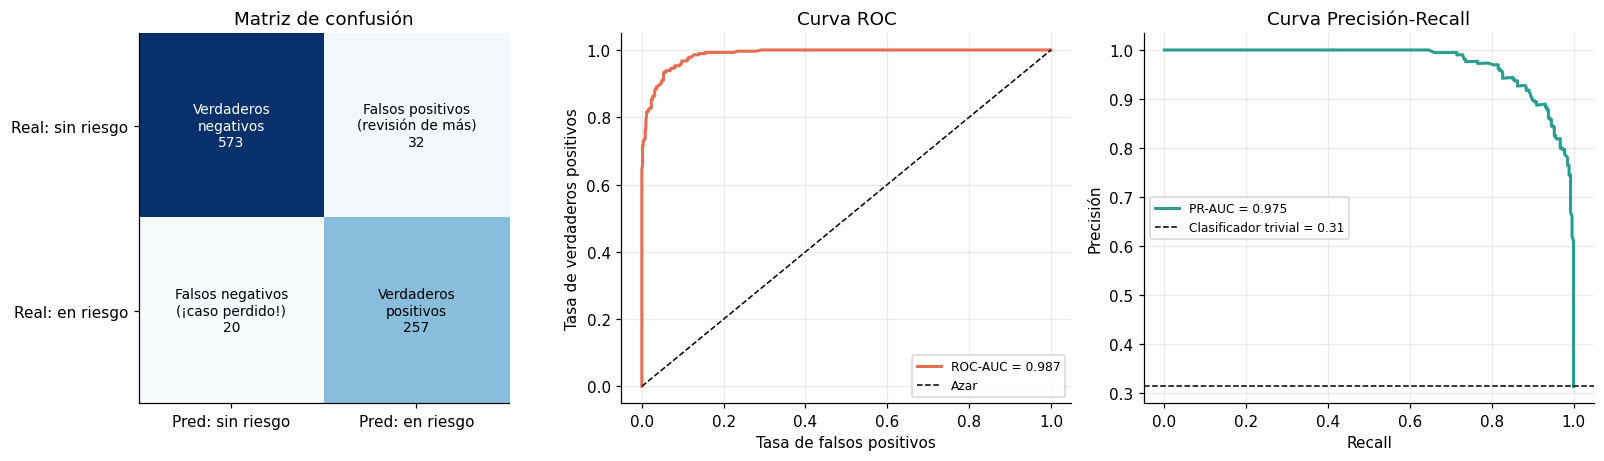

Falsos negativos: 20 estudiantes en riesgo que el sistema NO habría alertado.
Falsos positivos: 32 estudiantes alertados que igual habrían aprobado.


In [21]:
mc = confusion_matrix(y_prueba, predicciones)
vn, fp, fn, vp = int(mc[0, 0]), int(mc[0, 1]), int(mc[1, 0]), int(mc[1, 1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

axes[0].imshow(mc, cmap="Blues")
axes[0].set_xticks([0, 1], ["Pred: sin riesgo", "Pred: en riesgo"])
axes[0].set_yticks([0, 1], ["Real: sin riesgo", "Real: en riesgo"])
etiquetas = [["Verdaderos\nnegativos", "Falsos positivos\n(revisión de más)"],
             ["Falsos negativos\n(¡caso perdido!)", "Verdaderos\npositivos"]]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{etiquetas[i][j]}\n{mc[i, j]}", ha="center", va="center",
                     fontsize=9, color="white" if mc[i, j] > mc.max() / 2 else "black")
axes[0].set_title("Matriz de confusión")
axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_prueba, probabilidades)
axes[1].plot(fpr, tpr, color="#e76f51", lw=2,
             label=f"ROC-AUC = {resultados['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(fontsize=8)

prec, rec, _ = precision_recall_curve(y_prueba, probabilidades)
axes[2].plot(rec, prec, color="#2a9d8f", lw=2,
             label=f"PR-AUC = {resultados['PR-AUC (avg precision)']:.3f}")
axes[2].axhline(float(y_prueba.mean()), color="k", ls="--", lw=1,
                label=f"Clasificador trivial = {y_prueba.mean():.2f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisión")
axes[2].set_title("Curva Precisión-Recall")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / "06_evaluacion.png", bbox_inches="tight")
plt.show()

print(f"Falsos negativos: {fn} estudiantes en riesgo que el sistema NO habría alertado.")
print(f"Falsos positivos: {fp} estudiantes alertados que igual habrían aprobado.")

### 5.2 Elección del umbral según el costo pedagógico

El 0.5 por defecto es una convención estadística, no una decisión pedagógica. Aquí los dos
errores **no cuestan lo mismo**:

* **Falso negativo:** un estudiante que reprueba sin que nadie interviniera. Costo alto:
  repitencia, sobreedad y riesgo de abandono.
* **Falso positivo:** una tutoría que quizá no era imprescindible. Costo bajo: tiempo docente.

Se modela un costo relativo de **5 : 1** y se busca el umbral que minimiza el costo total,
verificando además que la carga de alertas sea operativamente viable.

Umbral de mínimo costo puro        : 0.24 (alertaría al 38.5% del aula)
Umbral aplicando la RESTRICCIÓN     : 0.37 (≤ 35% alertado y recall ≥ 80%)
Se adopta el segundo: un modelo que alerta a media aula no se usa en la práctica.

  Recall        : 0.9458
  Precisión     : 0.8590
  F2            : 0.9271
  % del aula alertado: 34.6%


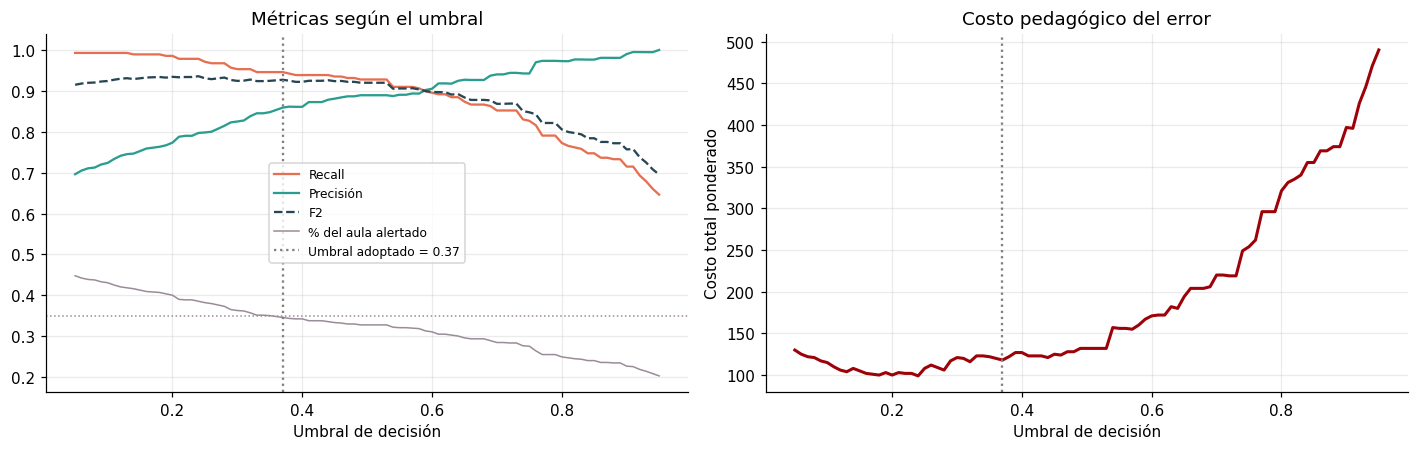

In [22]:
COSTO_FALSO_NEGATIVO = 5.0
COSTO_FALSO_POSITIVO = 1.0

umbrales = np.linspace(0.05, 0.95, 91)
registro_umbral = []
for u in umbrales:
    pred_u = (probabilidades >= u).astype(int)
    m = confusion_matrix(y_prueba, pred_u, labels=[0, 1])
    vn_u, fp_u, fn_u, vp_u = int(m[0, 0]), int(m[0, 1]), int(m[1, 0]), int(m[1, 1])
    registro_umbral.append({
        "umbral": float(u),
        "recall": recall_score(y_prueba, pred_u, zero_division=0),
        "precision": precision_score(y_prueba, pred_u, zero_division=0),
        "f1": f1_score(y_prueba, pred_u, zero_division=0),
        "f2": fbeta_score(y_prueba, pred_u, beta=2, zero_division=0),
        "costo": COSTO_FALSO_NEGATIVO * fn_u + COSTO_FALSO_POSITIVO * fp_u,
        "pct_alertados": float(pred_u.mean()),
    })

CAPACIDAD_MAXIMA = 0.35   # el docente no puede dar seguimiento intensivo a más del 35% del aula
RECALL_MINIMO = 0.80      # criterio de negocio definido en la Fase 1

tabla_umbral = pd.DataFrame(registro_umbral)

umbral_costo = float(tabla_umbral.loc[tabla_umbral["costo"].idxmin(), "umbral"])
factibles = tabla_umbral[(tabla_umbral["pct_alertados"] <= CAPACIDAD_MAXIMA) &
                         (tabla_umbral["recall"] >= RECALL_MINIMO)]

if len(factibles):
    UMBRAL_OPTIMO = float(factibles.loc[factibles["costo"].idxmin(), "umbral"])
    print(f"Umbral de mínimo costo puro        : {umbral_costo:.2f} "
          f"(alertaría al {float(tabla_umbral.loc[tabla_umbral['costo'].idxmin(), 'pct_alertados']):.1%} del aula)")
    print(f"Umbral aplicando la RESTRICCIÓN     : {UMBRAL_OPTIMO:.2f} "
          f"(≤ {CAPACIDAD_MAXIMA:.0%} alertado y recall ≥ {RECALL_MINIMO:.0%})")
    print("Se adopta el segundo: un modelo que alerta a media aula no se usa en la práctica.")
else:
    UMBRAL_OPTIMO = umbral_costo
    print("No hay umbral que cumpla ambas restricciones; se usa el de mínimo costo:",
          f"{UMBRAL_OPTIMO:.2f}")

fila_optima = tabla_umbral.loc[(tabla_umbral["umbral"] - UMBRAL_OPTIMO).abs().idxmin()]
print()
print(f"  Recall        : {fila_optima['recall']:.4f}")
print(f"  Precisión     : {fila_optima['precision']:.4f}")
print(f"  F2            : {fila_optima['f2']:.4f}")
print(f"  % del aula alertado: {fila_optima['pct_alertados']:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(tabla_umbral["umbral"], tabla_umbral["recall"], label="Recall", color="#e76f51")
axes[0].plot(tabla_umbral["umbral"], tabla_umbral["precision"], label="Precisión", color="#2a9d8f")
axes[0].plot(tabla_umbral["umbral"], tabla_umbral["f2"], label="F2", color="#264653", ls="--")
axes[0].plot(tabla_umbral["umbral"], tabla_umbral["pct_alertados"],
             label="% del aula alertado", color="#9a8c98", lw=1)
axes[0].axhline(CAPACIDAD_MAXIMA, color="#9a8c98", ls=":", lw=1)
axes[0].axvline(UMBRAL_OPTIMO, color="gray", ls=":", label=f"Umbral adoptado = {UMBRAL_OPTIMO:.2f}")
axes[0].set_xlabel("Umbral de decisión")
axes[0].set_title("Métricas según el umbral")
axes[0].legend(fontsize=8)

axes[1].plot(tabla_umbral["umbral"], tabla_umbral["costo"], color="#9d0208", lw=2)
axes[1].axvline(UMBRAL_OPTIMO, color="gray", ls=":")
axes[1].set_xlabel("Umbral de decisión")
axes[1].set_ylabel("Costo total ponderado")
axes[1].set_title("Costo pedagógico del error")

plt.tight_layout()
plt.savefig(DIR_FIGURAS / "07_umbral.png", bbox_inches="tight")
plt.show()

In [23]:
pred_opt = (probabilidades >= UMBRAL_OPTIMO).astype(int)
print(f"=== DESEMPEÑO FINAL · umbral = {UMBRAL_OPTIMO:.2f} ===")
print(classification_report(y_prueba, pred_opt, zero_division=0,
                            target_names=["Sin riesgo", "En riesgo"]))

criterios = {
    "Recall ≥ 0.80 (detectar 8 de cada 10 casos)":
        recall_score(y_prueba, pred_opt, zero_division=0) >= 0.80,
    "ROC-AUC ≥ 0.85":
        resultados["ROC-AUC"] >= 0.85,
    "F1 ≥ 0.75":
        f1_score(y_prueba, pred_opt, zero_division=0) >= 0.75,
    "Alertas ≤ 35% del aula (carga manejable)":
        float(pred_opt.mean()) <= 0.35,
}
print("=== VERIFICACIÓN DE LOS CRITERIOS DE ÉXITO DEFINIDOS EN LA FASE 1 ===")
for criterio, cumple in criterios.items():
    print(f"  [{'✓' if cumple else '✗'}] {criterio}")

=== DESEMPEÑO FINAL · umbral = 0.37 ===
              precision    recall  f1-score   support

  Sin riesgo       0.97      0.93      0.95       605
   En riesgo       0.86      0.95      0.90       277

    accuracy                           0.93       882
   macro avg       0.92      0.94      0.93       882
weighted avg       0.94      0.93      0.94       882

=== VERIFICACIÓN DE LOS CRITERIOS DE ÉXITO DEFINIDOS EN LA FASE 1 ===
  [✓] Recall ≥ 0.80 (detectar 8 de cada 10 casos)
  [✓] ROC-AUC ≥ 0.85
  [✓] F1 ≥ 0.75
  [✓] Alertas ≤ 35% del aula (carga manejable)


### 5.3 Explicabilidad: ¿por qué el modelo alerta?

Un sistema que afecta la trayectoria escolar de un adolescente **no puede ser una caja
negra**. Se usa **importancia por permutación**, que mide cuánto se degrada el ROC-AUC al
desordenar cada variable, y funciona con cualquier modelo.

,variable,importancia,desv
0,calificacion_p1,0.0798,0.0060
1,calificacion_p2,0.0792,0.0075
2,ausencias_injustificadas,0.0046,0.0010
3,promedio_competencias,0.0040,0.0018
4,pct_practicas_entregadas,0.0028,0.0011
5,participacion,0.0024,0.0008
6,horas_estudio_semana,0.0013,0.0010
7,tardanzas,0.0003,0.0007
8,tanda,0.0003,0.0002
9,recuperaciones_p1_p2,0.0002,0.0002


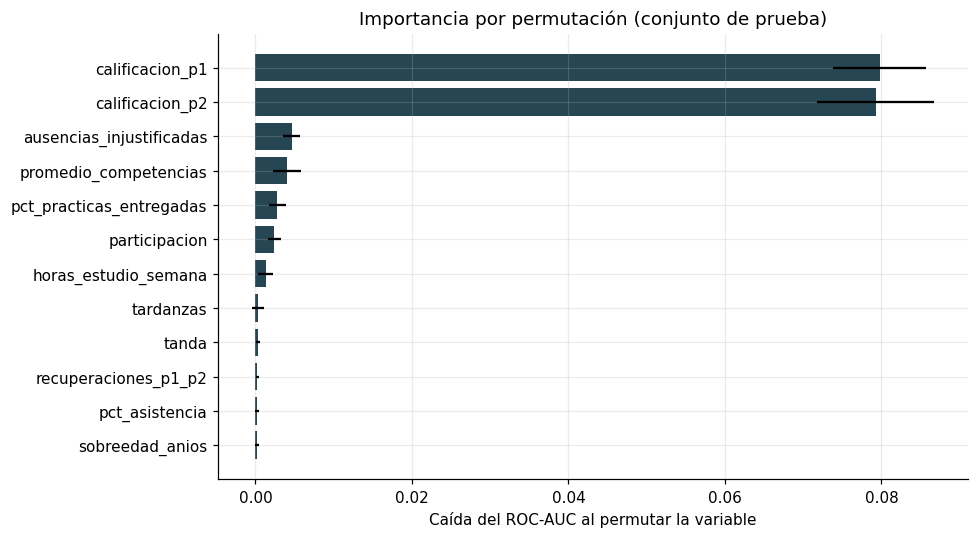

In [24]:
from sklearn.inspection import permutation_importance

importancia = permutation_importance(
    modelo_produccion, X_prueba, y_prueba,
    n_repeats=10, random_state=SEMILLA, n_jobs=-1, scoring="roc_auc")

tabla_importancia = (pd.DataFrame({
    "variable": X_prueba.columns,
    "importancia": importancia.importances_mean,
    "desv": importancia.importances_std,
}).sort_values("importancia", ascending=False).reset_index(drop=True))

display(tabla_importancia.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
top = tabla_importancia.head(12).iloc[::-1]
ax.barh(top["variable"], top["importancia"], xerr=top["desv"], color="#264653")
ax.set_xlabel("Caída del ROC-AUC al permutar la variable")
ax.set_title("Importancia por permutación (conjunto de prueba)")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "08_importancia.png", bbox_inches="tight")
plt.show()

### 5.4 Auditoría de equidad *(fairness)*

Un modelo puede tener un recall global excelente y, aun así, fallar sistemáticamente con
un subgrupo: por ejemplo, detectar bien en la tanda matutina y mal en la vespertina. Se
audita el desempeño por grado y por tanda.

In [25]:
auditoria = X_prueba.copy()
auditoria["real"] = y_prueba.values
auditoria["prediccion"] = pred_opt
auditoria["probabilidad"] = probabilidades


def metricas_por_grupo(df, columna):
    filas = []
    for valor, sub in df.groupby(columna, observed=True):
        if sub["real"].nunique() < 2:
            continue
        filas.append({
            columna: valor,
            "n": int(len(sub)),
            "tasa_real_riesgo": float(sub["real"].mean()),
            "tasa_alertas": float(sub["prediccion"].mean()),
            "recall": recall_score(sub["real"], sub["prediccion"], zero_division=0),
            "precision": precision_score(sub["real"], sub["prediccion"], zero_division=0),
        })
    return pd.DataFrame(filas).round(3)


for columna in ["nivel", "tanda", "apoyo_familiar"]:
    print(f"--- Desempeño por {columna} ---")
    display(metricas_por_grupo(auditoria, columna))

recalls = metricas_por_grupo(auditoria, "tanda")["recall"]
brecha = float(recalls.max() - recalls.min()) if len(recalls) else 0.0
print(f"Brecha máxima de recall entre tandas: {brecha:.3f}")
print("Lectura: una brecha por encima de 0.10 exigiría revisar el modelo o recolectar",
      "más datos del grupo desfavorecido antes de poner el sistema en producción.")

--- Desempeño por nivel ---


,nivel,n,tasa_real_riesgo,tasa_alertas,recall,precision
0,4to,462,0.312,0.355,0.965,0.848
1,5to,162,0.290,0.272,0.851,0.909
2,6to,258,0.333,0.376,0.965,0.856


--- Desempeño por tanda ---


,tanda,n,tasa_real_riesgo,tasa_alertas,recall,precision
0,Extendida,366,0.301,0.336,0.973,0.870
1,Matutina,324,0.312,0.343,0.950,0.865
2,Vespertina,192,0.344,0.370,0.894,0.831


--- Desempeño por apoyo_familiar ---


,apoyo_familiar,n,tasa_real_riesgo,tasa_alertas,recall,precision
0,Alto,252,0.187,0.234,0.979,0.780
1,Bajo,186,0.618,0.645,0.957,0.917
2,Medio,444,0.259,0.284,0.922,0.841


Brecha máxima de recall entre tandas: 0.079
Lectura: una brecha por encima de 0.10 exigiría revisar el modelo o recolectar más datos del grupo desfavorecido antes de poner el sistema en producción.


### 5.5 Análisis de errores: ¿a quién se le escapa el modelo?

Los falsos negativos son el error que importa. Se revisa su perfil para entender el límite
del sistema y comunicarlo al docente.

In [26]:
falsos_negativos = auditoria[(auditoria["real"] == 1) & (auditoria["prediccion"] == 0)]
verdaderos_positivos = auditoria[(auditoria["real"] == 1) & (auditoria["prediccion"] == 1)]

comparacion = pd.DataFrame({
    "Falsos negativos (no alertados)": falsos_negativos[rpi.COLUMNAS_NUMERICAS].mean(),
    "Verdaderos positivos (alertados)": verdaderos_positivos[rpi.COLUMNAS_NUMERICAS].mean(),
}).round(2)
comparacion["diferencia"] = (comparacion.iloc[:, 0] - comparacion.iloc[:, 1]).round(2)
display(comparacion)

print(f"Casos no detectados: {len(falsos_negativos)} de {int(y_prueba.sum())} en riesgo "
      f"({len(falsos_negativos) / max(1, int(y_prueba.sum())):.1%})")
print("\nPerfil típico del caso que se escapa: estudiante con indicadores aceptables al")
print("corte de P2 que se deteriora en la segunda mitad del año. Ningún modelo puede")
print("predecir un evento posterior no observable (enfermedad, mudanza, trabajo infantil).")
print("Por eso el sistema exige RE-EVALUAR al cierre del Período 3.")

,Falsos negativos (no alertados),Verdaderos positivos (alertados),diferencia
calificacion_p1,71.07,60.10,10.97
calificacion_p2,73.06,59.32,13.74
promedio_competencias,71.83,59.74,12.09
pct_asistencia,90.55,85.66,4.89
tardanzas,2.07,2.42,-0.35
ausencias_injustificadas,9.40,14.16,-4.76
pct_practicas_entregadas,80.81,77.86,2.95
participacion,6.23,5.43,0.80
sobreedad_anios,0.47,0.78,-0.31
recuperaciones_p1_p2,0.67,1.82,-1.15


Casos no detectados: 15 de 277 en riesgo (5.4%)

Perfil típico del caso que se escapa: estudiante con indicadores aceptables al
corte de P2 que se deteriora en la segunda mitad del año. Ningún modelo puede
predecir un evento posterior no observable (enfermedad, mudanza, trabajo infantil).
Por eso el sistema exige RE-EVALUAR al cierre del Período 3.


---
## 6. Fase 5 — Despliegue *(Deployment)*

Tres artefactos de despliegue:

1. **`models/modelo_riesgo.joblib`** — pipeline completo para la app Streamlit.
2. **`models/model_card.json`** — tarjeta del modelo con métricas, supuestos y límites.
3. **`models/modelo_navegador.json`** — una regresión logística exportada como coeficientes,
   para que la **landing page prediga dentro del navegador**, sin servidor y sin que los
   datos del estudiante salgan de la computadora del centro educativo.

In [27]:
import joblib
from datetime import datetime

RUTA_MODELO = DIR_MODELOS / "modelo_riesgo.joblib"

paquete = {
    "pipeline": modelo_produccion,
    "umbral": round(float(UMBRAL_OPTIMO), 2),
    "umbral_medio": round(float(max(0.15, UMBRAL_OPTIMO * 0.60)), 2),
    "columnas_numericas": list(rpi.COLUMNAS_NUMERICAS),
    "columnas_categoricas": list(rpi.COLUMNAS_CATEGORICAS),
    "columnas": list(X.columns),
    "version": "1.0.0",
    "entrenado": datetime.now().strftime("%Y-%m-%d %H:%M"),
}
joblib.dump(paquete, RUTA_MODELO)
print("Modelo guardado en:", RUTA_MODELO.relative_to(RAIZ),
      f"({RUTA_MODELO.stat().st_size / 1024:.0f} KB)")

# --- Prueba de humo: cargar y predecir exactamente como hará la app --------
cargado = joblib.load(RUTA_MODELO)
caso = {
    "calificacion_p1": 58, "calificacion_p2": "54", "promedio_competencias": 57.5,
    "pct_asistencia": 74, "tardanzas": 9, "ausencias_injustificadas": 6,
    "pct_practicas_entregadas": 55, "participacion": 4, "sobreedad_anios": 1,
    "recuperaciones_p1_p2": 2, "horas_estudio_semana": None,
    "nivel": "5to", "asignatura": "Matemática",
    "apoyo_familiar": "Bajo", "tanda": "Vespertina",
}
fila = pd.DataFrame([{
    **{c: rpi.num(caso.get(c), rpi.ESQUEMA_FEATURES[c]["default"]) for c in cargado["columnas_numericas"]},
    **{c: rpi.texto(caso.get(c), rpi.ESQUEMA_FEATURES[c]["default"]) for c in cargado["columnas_categoricas"]},
}])[cargado["columnas"]]

p = float(cargado["pipeline"].predict_proba(fila)[:, 1][0])
print(f"\nPrueba de humo -> probabilidad de riesgo: {p:.1%} · banda: "
      f"{rpi.banda_riesgo(p, cargado['umbral_medio'], cargado['umbral'])}")
print("(Nótese que el caso trae un texto '54' y un None: el casteo defensivo los absorbe.)")

Modelo guardado en: models/modelo_riesgo.joblib (37 KB)

Prueba de humo -> probabilidad de riesgo: 100.0% · banda: ALTO
(Nótese que el caso trae un texto '54' y un None: el casteo defensivo los absorbe.)


In [28]:
from sklearn.pipeline import Pipeline as _Pipeline

# Regresión logística dedicada para la inferencia en el navegador
modelo_navegador = _Pipeline([
    ("preproceso", preprocesador),
    ("modelo", LogisticRegression(max_iter=3000, class_weight="balanced",
                                  random_state=SEMILLA)),
])
modelo_navegador.fit(X_entrena, y_entrena)

prob_nav = modelo_navegador.predict_proba(X_prueba)[:, 1]
auc_nav = roc_auc_score(y_prueba, prob_nav)
print(f"ROC-AUC de la versión para navegador: {auc_nav:.4f} "
      f"(modelo de producción: {resultados['ROC-AUC']:.4f})")

import despliegue  # noqa: E402  (src/despliegue.py)

especificacion = despliegue.exportar_modelo_navegador(
    pipeline=modelo_navegador,
    columnas_numericas=rpi.COLUMNAS_NUMERICAS,
    columnas_categoricas=rpi.COLUMNAS_CATEGORICAS,
    umbral_alto=round(float(UMBRAL_OPTIMO), 2),
    umbral_medio=round(float(max(0.15, UMBRAL_OPTIMO * 0.60)), 2),
    metricas={"roc_auc": float(auc_nav)},
    esquema=rpi.ESQUEMA_FEATURES,
)

RUTA_MODELO_NAV = DIR_MODELOS / "modelo_navegador.json"
RUTA_MODELO_NAV.write_text(json.dumps(especificacion, ensure_ascii=False, indent=2),
                           encoding="utf-8")
print("Especificación para el navegador:", RUTA_MODELO_NAV.relative_to(RAIZ))

# Verificación: el cálculo en JavaScript debe dar lo mismo que scikit-learn
verificacion = despliegue.verificar_equivalencia(especificacion, modelo_navegador,
                                                 X_prueba.head(200))
print(f"Diferencia máxima entre la fórmula exportada y scikit-learn: "
      f"{verificacion['max_diferencia']:.2e}")
assert verificacion["max_diferencia"] < 1e-8, "La exportación no reproduce el modelo"
print("✓ La landing page calculará exactamente la misma probabilidad que este cuaderno.")

ROC-AUC de la versión para navegador: 0.9871 (modelo de producción: 0.9872)
Especificación para el navegador: models/modelo_navegador.json
Diferencia máxima entre la fórmula exportada y scikit-learn: 2.22e-16
✓ La landing page calculará exactamente la misma probabilidad que este cuaderno.


In [29]:
tarjeta = {
    "nombre": "Registro Pedagógico Inteligente — Alerta temprana de no promoción",
    "version": paquete["version"],
    "fecha_entrenamiento": paquete["entrenado"],
    "proposito": ("Estimar, al cierre del Período 2, la probabilidad de que un estudiante "
                  "no alcance 70 puntos en la calificación final ordinaria de una asignatura, "
                  "para activar a tiempo la Recuperación Pedagógica."),
    "tipo_de_modelo": mejor_nombre + (" + calibración isotónica" if usar_calibrado else ""),
    "hiperparametros": {k: str(v) for k, v in busqueda.best_params_.items()},
    "datos_de_entrenamiento": {
        "origen": "Estructura real del libro 3RO_B_REGISTRO_ESCOLAR_2026_2027.xlsx "
                  "(matrícula, cursos, asignaturas y reglas MINERD) con desempeño simulado",
        "registros": int(len(datos)),
        "estudiantes": int(datos["id_estudiante"].nunique()),
        "anios_escolares": list(ANIOS_HISTORICOS),
        "tasa_de_riesgo": float(datos[rpi.COLUMNA_OBJETIVO].mean()),
    },
    "variables_de_entrada": list(X.columns),
    "variables_excluidas_por_etica": ["nombre", "sexo", "nacionalidad"],
    "umbrales": {"medio": float(paquete["umbral_medio"]), "alto": float(UMBRAL_OPTIMO)},
    "metricas_en_prueba": {k: float(v) for k, v in resultados.items()},
    "metricas_umbral_optimo": {
        "recall": float(recall_score(y_prueba, pred_opt, zero_division=0)),
        "precision": float(precision_score(y_prueba, pred_opt, zero_division=0)),
        "f1": float(f1_score(y_prueba, pred_opt, zero_division=0)),
        "f2": float(fbeta_score(y_prueba, pred_opt, beta=2, zero_division=0)),
        "pct_alertado": float(pred_opt.mean()),
    },
    "limitaciones": [
        "Entrenado con desempeño SIMULADO: las métricas no son evidencia sobre estudiantes "
        "reales. Debe reentrenarse con las calificaciones reales antes de tomar decisiones.",
        "No predice eventos posteriores al corte de P2 (enfermedad, migración, trabajo).",
        "Es una herramienta de apoyo: la decisión pedagógica corresponde siempre al docente.",
        "No debe usarse para clasificar, agrupar ni rotular estudiantes de forma permanente.",
    ],
    "uso_previsto": "Apoyo al docente y al equipo de gestión del centro educativo.",
    "uso_no_previsto": ["Selección o rechazo de matrícula",
                        "Evaluación del desempeño docente",
                        "Cualquier decisión automática sin revisión humana"],
}

RUTA_TARJETA = DIR_MODELOS / "model_card.json"
RUTA_TARJETA.write_text(json.dumps(tarjeta, ensure_ascii=False, indent=2), encoding="utf-8")
print("Tarjeta del modelo guardada en:", RUTA_TARJETA.relative_to(RAIZ))
print(json.dumps({k: tarjeta[k] for k in
                  ["nombre", "version", "tipo_de_modelo", "umbrales", "metricas_umbral_optimo"]},
                 ensure_ascii=False, indent=2))

Tarjeta del modelo guardada en: models/model_card.json
{
  "nombre": "Registro Pedagógico Inteligente — Alerta temprana de no promoción",
  "version": "1.0.0",
  "tipo_de_modelo": "Regresión Logística + calibración isotónica",
  "umbrales": {
    "medio": 0.22,
    "alto": 0.36999999999999994
  },
  "metricas_umbral_optimo": {
    "recall": 0.9458483754512635,
    "precision": 0.8590163934426229,
    "f1": 0.9003436426116839,
    "f2": 0.9271054493984431,
    "pct_alertado": 0.3458049886621315
  }
}


### 6.1 Generación de la landing page

La landing page es el **punto de captura del registro pedagógico**: el docente llena el
formulario con lo que ya tiene en su libro y obtiene la alerta al instante. La
especificación del modelo se inyecta dentro del HTML, de modo que el archivo es
autónomo: se puede abrir con doble clic, funciona sin internet y **ningún dato del
estudiante viaja por la red**.

In [30]:
RUTA_PLANTILLA = RAIZ / "landing" / "_plantilla_index.html"
RUTA_LANDING = RAIZ / "landing" / "index.html"

resumen_despliegue = despliegue.construir_landing(
    plantilla=RUTA_PLANTILLA,
    especificacion=especificacion,
    salida=RUTA_LANDING,
    contexto={
        "asignaturas": sorted(catalogo["asignatura"].unique().tolist()),
        "cursos": sorted(estudiantes["curso"].unique().tolist()),
        "estudiantes": (estudiantes[["id_estudiante", "estudiante", "curso", "nivel"]]
                        .to_dict(orient="records")),
        "modelo": tarjeta["tipo_de_modelo"],
        "roc_auc": round(float(auc_nav), 3),
        "recall": round(float(tarjeta["metricas_umbral_optimo"]["recall"]), 3),
        "version": tarjeta["version"],
        "fecha": tarjeta["fecha_entrenamiento"],
    },
)
print("Landing page generada:", RUTA_LANDING.relative_to(RAIZ),
      f"({resumen_despliegue['bytes'] / 1024:.0f} KB, autónoma)")

Landing page generada: landing/index.html (58 KB, autónoma)


### 6.2 Puesta en marcha sobre el curso actual (2026-2027)

Simulación del uso real: se toma la matrícula del libro, se construye el corte del
Período 2 y se genera el **reporte de alertas** que recibiría el equipo de gestión.

In [31]:
cohorte_actual = rpi.simular_historico(
    estudiantes=estudiantes, catalogo=catalogo,
    anios=("2026-2027",), asignaturas_por_estudiante=4, semilla=2027)

entrada_actual = cohorte_actual[GRUPO_A_PREDICTORES].copy()
for col in rpi.COLUMNAS_NUMERICAS:
    entrada_actual[col] = pd.to_numeric(entrada_actual[col], errors="coerce").astype("float64")
for col in rpi.COLUMNAS_CATEGORICAS:
    entrada_actual[col] = entrada_actual[col].astype(str)

prob_actual = modelo_produccion.predict_proba(entrada_actual)[:, 1]

alertas = cohorte_actual[["id_estudiante", "estudiante", "curso", "asignatura",
                          "calificacion_p1", "calificacion_p2", "pct_asistencia",
                          "pct_practicas_entregadas"]].copy()
alertas["probabilidad_riesgo"] = np.round(prob_actual, 4)
alertas["banda"] = [rpi.banda_riesgo(p, paquete["umbral_medio"], UMBRAL_OPTIMO)
                    for p in prob_actual]
alertas = alertas.sort_values("probabilidad_riesgo", ascending=False).reset_index(drop=True)

RUTA_ALERTAS = RAIZ / "reports" / "alertas_periodo2_2026_2027.csv"
alertas.to_csv(RUTA_ALERTAS, index=False, encoding="utf-8")

print("Distribución de alertas del curso 2026-2027:")
print(alertas["banda"].value_counts().reindex(["ALTO", "MEDIO", "BAJO"]).fillna(0).astype(int).to_string())
print(f"\nEstudiantes distintos en banda ALTO: "
      f"{alertas.loc[alertas['banda'] == 'ALTO', 'id_estudiante'].nunique()} "
      f"de {alertas['id_estudiante'].nunique()}")
print("Reporte guardado en:", RUTA_ALERTAS.relative_to(RAIZ))
display(alertas.head(10))

Distribución de alertas del curso 2026-2027:
banda
ALTO     263
MEDIO     21
BAJO     496

Estudiantes distintos en banda ALTO: 97 de 195
Reporte guardado en: reports/alertas_periodo2_2026_2027.csv


,id_estudiante,estudiante,curso,asignatura,calificacion_p1,calificacion_p2,pct_asistencia,pct_practicas_entregadas,probabilidad_riesgo,banda
0,6TOB22,Jarlym Emmanuel Valdez De La Cruz,6TO B,Educación Artística,59.58,55.14,81.94,65.19,1.0,ALTO
1,6TOB11,Vairon Alberto Javier Mieses,6TO B,Ciencias y Tecnología. Física y Computación,55.24,52.43,92.34,64.25,1.0,ALTO
2,6TOB12,Alberto Jose Luis,6TO B,Ciencias Sociales,49.70,46.60,94.65,80.53,1.0,ALTO
3,6TOB12,Alberto Jose Luis,6TO B,Humanidades y Lenguas Modernas. Análisis Críti...,60.35,53.38,94.65,86.37,1.0,ALTO
4,6TOB11,Vairon Alberto Javier Mieses,6TO B,Ciencias Sociales,53.24,62.30,92.34,60.07,1.0,ALTO
5,4TOA16,Ysmil Luciano,4TO A,Ciencias y Tecnología. Física y Computación,52.91,52.84,90.65,69.03,1.0,ALTO
6,4TOA16,Ysmil Luciano,4TO A,Humanidades y Ciencias Sociales. Análisis y Pr...,59.97,57.36,90.65,68.88,1.0,ALTO
7,6TOB7,Josue David Enseñat Mercedes,6TO B,Humanidades y Lenguas Modernas. Análisis y Pro...,59.90,55.84,93.17,63.45,1.0,ALTO
8,4TOA8,Jhorwan Diaz Guerrero,4TO A,Ciencias de la Naturaleza,62.32,52.92,80.91,89.26,1.0,ALTO
9,4TOA7,Angel Gabriel De Los Santos Florencio,4TO A,Humanidades y Ciencias Sociales. Análisis y Pr...,54.79,50.68,84.23,71.42,1.0,ALTO


In [32]:
caso_prioritario = alertas.iloc[0]
datos_caso = cohorte_actual.loc[
    (cohorte_actual["id_estudiante"] == caso_prioritario["id_estudiante"]) &
    (cohorte_actual["asignatura"] == caso_prioritario["asignatura"])].iloc[0].to_dict()

banda = rpi.banda_riesgo(caso_prioritario["probabilidad_riesgo"],
                         paquete["umbral_medio"], UMBRAL_OPTIMO)

print("=" * 72)
print("FICHA DE ACOMPAÑAMIENTO PEDAGÓGICO")
print("=" * 72)
print(f"Estudiante : {caso_prioritario['estudiante']}  ({caso_prioritario['curso']})")
print(f"Asignatura : {caso_prioritario['asignatura']}")
print(f"Riesgo     : {caso_prioritario['probabilidad_riesgo']:.1%}  ·  BANDA {banda}")
print(f"Indicadores: P1={datos_caso['calificacion_p1']:.0f} · P2={datos_caso['calificacion_p2']:.0f} · "
      f"Asistencia={datos_caso['pct_asistencia']:.0f}% · "
      f"Prácticas={datos_caso['pct_practicas_entregadas']:.0f}%")
print("-" * 72)
print("ACCIONES SUGERIDAS:")
for i, r in enumerate(rpi.recomendaciones_pedagogicas(datos_caso, banda), 1):
    print(f"  {i}. {r}")
print("=" * 72)

FICHA DE ACOMPAÑAMIENTO PEDAGÓGICO
Estudiante : Jarlym Emmanuel Valdez De La Cruz  (6TO B)
Asignatura : Educación Artística
Riesgo     : 100.0%  ·  BANDA ALTO
Indicadores: P1=60 · P2=55 · Asistencia=82% · Prácticas=65%
------------------------------------------------------------------------
ACCIONES SUGERIDAS:
  1. PRIORIDAD ALTA: incluir al estudiante en el reporte semanal del equipo de gestión y levantar acta de seguimiento.
  2. Asistencia irregular: acordar compromiso de puntualidad con la familia.
  3. 5 o más ausencias injustificadas: registrar en el SGCE y abrir seguimiento.
  4. Menos del 70% de prácticas entregadas: asignar tutoría entre pares y plan de entrega escalonada de las actividades pendientes.
  5. Dos períodos consecutivos por debajo de 70: iniciar de inmediato la Recuperación Pedagógica prevista en la planificación.
  6. Competencias C1-C4 por debajo de 65: reforzar indicadores de logro con evaluación formativa y retroalimentación semanal.


---
## 7. Fase 6 — Monitoreo y mantenimiento

CRISP-ML(Q) añade esta fase precisamente porque un modelo educativo **caduca**: cambia la
matrícula, cambia el docente, cambian las estrategias de evaluación. Se monitorean tres cosas.

### 7.1 Deriva de datos *(data drift)* con el Índice de Estabilidad de Población (PSI)

| PSI | Interpretación | Acción |
|---|---|---|
| < 0.10 | Población estable | Seguir monitoreando |
| 0.10 – 0.25 | Deriva moderada | Revisar la variable e informar al equipo |
| > 0.25 | Deriva severa | **Reentrenar** el modelo |

,variable,psi,estado
10,horas_estudio_semana,0.0953,ESTABLE
1,calificacion_p2,0.0760,ESTABLE
2,promedio_competencias,0.0685,ESTABLE
0,calificacion_p1,0.0571,ESTABLE
3,pct_asistencia,0.0379,ESTABLE
7,participacion,0.0209,ESTABLE
4,tardanzas,0.0208,ESTABLE
5,ausencias_injustificadas,0.0131,ESTABLE
6,pct_practicas_entregadas,0.0072,ESTABLE
9,recuperaciones_p1_p2,0.0025,ESTABLE


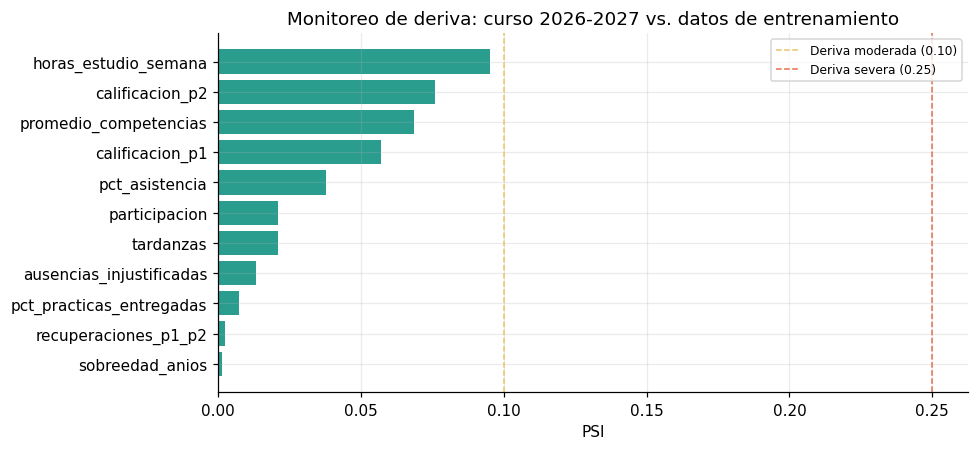

In [33]:
def psi(esperado, observado, n_bins: int = 10) -> float:
    '''Índice de Estabilidad de Población entre dos distribuciones numéricas.'''
    esperado = pd.to_numeric(pd.Series(esperado), errors="coerce").dropna().to_numpy()
    observado = pd.to_numeric(pd.Series(observado), errors="coerce").dropna().to_numpy()
    if esperado.size == 0 or observado.size == 0:
        return 0.0
    cortes = np.unique(np.quantile(esperado, np.linspace(0, 1, n_bins + 1)))
    if cortes.size < 3:
        return 0.0
    cortes[0], cortes[-1] = -np.inf, np.inf
    p_esp = np.histogram(esperado, bins=cortes)[0] / esperado.size
    p_obs = np.histogram(observado, bins=cortes)[0] / observado.size
    p_esp = np.clip(p_esp, 1e-6, None)
    p_obs = np.clip(p_obs, 1e-6, None)
    return float(np.sum((p_obs - p_esp) * np.log(p_obs / p_esp)))


reporte_psi = pd.DataFrame([
    {"variable": c,
     "psi": round(psi(X_entrena[c], entrada_actual[c]), 4)}
    for c in rpi.COLUMNAS_NUMERICAS
]).sort_values("psi", ascending=False)

def estado(v):
    return "ESTABLE" if v < 0.10 else ("REVISAR" if v < 0.25 else "REENTRENAR")

reporte_psi["estado"] = reporte_psi["psi"].map(estado)
display(reporte_psi)

fig, ax = plt.subplots(figsize=(9, 4.2))
colores_psi = {"ESTABLE": "#2a9d8f", "REVISAR": "#e9c46a", "REENTRENAR": "#e76f51"}
ax.barh(reporte_psi["variable"][::-1], reporte_psi["psi"][::-1],
        color=[colores_psi[e] for e in reporte_psi["estado"][::-1]])
ax.axvline(0.10, color="#e9c46a", ls="--", lw=1, label="Deriva moderada (0.10)")
ax.axvline(0.25, color="#e76f51", ls="--", lw=1, label="Deriva severa (0.25)")
ax.set_xlabel("PSI")
ax.set_title("Monitoreo de deriva: curso 2026-2027 vs. datos de entrenamiento")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "09_drift_psi.png", bbox_inches="tight")
plt.show()

### 7.2 Plan de mantenimiento

| Cuándo | Qué se revisa | Responsable | Disparador de reentrenamiento |
|---|---|---|---|
| Cierre de cada período (4 veces al año) | PSI de las variables, distribución de bandas | Coordinador pedagógico | PSI > 0.25 en 2 o más variables |
| Fin de año escolar | Recall real: ¿cuántos alertados efectivamente reprobaron? | Equipo de gestión | Recall observado < 0.70 |
| Cada año escolar | Reentrenamiento completo con los datos del año que cerró | Docente de Informática / responsable TIC | Siempre |
| Cambio de normativa MINERD | Reglas de promoción en `PARAMETROS_MINERD` | Dirección del centro | Inmediato |

### 7.3 Registro de decisiones para auditoría

Cada alerta que la app emite se guarda con: fecha, versión del modelo, valores de entrada,
probabilidad, banda y **la decisión que tomó el docente**. Ese registro permite dos cosas:
auditar el sistema y, sobre todo, construir el conjunto de datos reales con el que se
entrenará la versión 2.0.

In [34]:
bitacora = {
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "modelo_version": tarjeta["version"],
    "registros_evaluados": int(len(alertas)),
    "alertas_alto": int((alertas["banda"] == "ALTO").sum()),
    "alertas_medio": int((alertas["banda"] == "MEDIO").sum()),
    "psi_maximo": float(reporte_psi["psi"].max()),
    "variables_en_deriva": reporte_psi.loc[reporte_psi["psi"] >= 0.25, "variable"].tolist(),
    "criterios_exito": {k: bool(v) for k, v in criterios.items()},
}
RUTA_BITACORA = RAIZ / "reports" / "bitacora_monitoreo.json"
RUTA_BITACORA.write_text(json.dumps(bitacora, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(bitacora, ensure_ascii=False, indent=2))

{
  "fecha": "2026-09-19 01:37",
  "modelo_version": "1.0.0",
  "registros_evaluados": 780,
  "alertas_alto": 263,
  "alertas_medio": 21,
  "psi_maximo": 0.0953,
  "variables_en_deriva": [],
  "criterios_exito": {
    "Recall ≥ 0.80 (detectar 8 de cada 10 casos)": true,
    "ROC-AUC ≥ 0.85": true,
    "F1 ≥ 0.75": true,
    "Alertas ≤ 35% del aula (carga manejable)": true
  }
}


---
## 8. Conclusiones

1. **El problema quedó bien planteado antes de tocar un algoritmo.** La decisión más
   importante del proyecto no fue elegir Random Forest sobre otro modelo, sino fijar el
   *momento* de la predicción (cierre de P2) y el *costo asimétrico* de los errores. Un
   modelo con 99 % de exactitud entrenado con las notas de P4 habría sido inservible.

2. **La ausencia de etiquetas se declaró, no se escondió.** El libro entregado está vacío
   de calificaciones porque el año escolar apenas comienza. Se documentó el proceso
   generador de la simulación y se dejó el camino listo para sustituirla por datos reales
   sin modificar el resto del cuaderno.

3. **Lo que el modelo aprende coincide con lo que el docente ya sabe**: las notas de los
   primeros períodos, el cumplimiento de las prácticas y la asistencia explican la mayor
   parte del riesgo. El valor del sistema no es descubrir algo nuevo, sino **hacerlo a
   tiempo, para los 195 estudiantes a la vez, y con una acción concreta asociada**.

4. **La predicción sin recomendación es inútil.** Por eso cada alerta sale acompañada de
   reglas pedagógicas explícitas y trazables hasta la normativa del centro.

5. **Límites asumidos:** el sistema no reemplaza el juicio docente, no predice eventos
   externos posteriores al corte, y debe reentrenarse cada año escolar.

### Cómo continuar

* Sustituir `simular_historico()` por la lectura real de las hojas `Calificación`,
  `Prácticas` y `Asistencia` cuando el docente cierre el Período 2.
* Incorporar el registro de la app al conjunto de entrenamiento (aprendizaje continuo).
* Añadir explicaciones locales con SHAP para justificar cada alerta individual.
* Evaluar el impacto real: comparar la tasa de promoción de los cursos con y sin el
  sistema durante un año escolar completo.